# Chapter 4 — General Framework and Further Results

This notebook contains the numerical experiments supporting Chapter 4. Chapter 3 introduced the Gibbs softmax and combination maps separately; the present chapter first connects them through a common optimisation programme and then extends the analysis to broader signal objects, multiple signals, and classical-portfolio recovery. The notebook follows the order of the chapter:

- **Experiment 4.1 — entropy regularisation and feasible sets.** Compares the softmax edge, the entropy-regularised interior, the sparse long-only M--V boundary, and the budget hyperplane. It separates the effect of changing the objective from the effect of changing the feasible set.
- **Experiment 4.2 — market-level signal.** Adds the same scalar signal to every asset score and tests whether a map benefits from information that contains no cross-sectional ranking.
- **Experiment 4.3 — measuring signal precision.** Introduces a controlled diffusion-information dial and a top-$k$ benchmark, then constructs an exchange rate between drift information and outcome-informed set information.
- **Experiment 4.4 — comparing signal forms.** Holds the underlying drift information fixed while representing it through cardinal scores, ranks, Gaussian-inferred ranks, or a median split.
- **Experiment 4.5 — combining correlated drift signals.** Studies how the optimal loading on a second, less accurate signal changes with the correlation between forecast errors.
- **Experiment 4.6 — recovery of classical portfolios.** Measures how closely noisy signals can reproduce tangency, long-only tangency, and GMV targets, and compares recovery-optimal strength with CE-optimal strength.

The experiments retain the main Chapter 3 design: $N=20$ assets, one-period GBM returns, $\gamma=5$, $30{,}000$ Monte-Carlo replications, and performance measured by mean--variance certainty equivalent relative to equal weight. Common random numbers are used within comparisons. For the combination map, alternatives are evaluated on a common intersection mask under the stated normaliser rule. The outcome-informed signals in Experiment 4.3 are diagnostic benchmarks rather than implementable trading strategies. Numerical outputs and validation checks are kept here; the fuller financial interpretation is given in the thesis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(42)

# ---------------- parameters (identical to Chapter 3) ----------------
N, dt, sigma  = 20, 1.0, 0.20
mu_bar, sigma_mu = 0.05, 0.05
gamma, n_sims = 5.0, 30_000

beta_grid  = np.linspace(0.0, 120.0, 121)

# ---------------- common random numbers (identical draw order to Chapter 3) ----------------
mu   = mu_bar + sigma_mu * rng.standard_normal((n_sims, N))
eps0 = rng.standard_normal((n_sims, N))
phi  = rng.standard_normal((n_sims, N))
R = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0

rng_gf = np.random.default_rng(4444)
e2_raw = rng_gf.standard_normal((n_sims, N))   # second drift signal's independent noise (Exp 4.5)
M_mkt  = 0.05 * rng_gf.standard_normal((n_sims, 1))   # market-level drift component (Exp 4.2)

def softmax_weights(s, beta):
    z = beta * s
    z -= z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def ce_of(port):
    """Mean-variance certainty equivalent of one simulated portfolio-return vector.

    This is the common evaluator throughout Chapter 4, including shortable portfolios.
    """
    port = np.asarray(port)
    return port.mean() - 0.5 * gamma * port.var(ddof=0)

def best_beta(s, R_mat, grid=beta_grid):
    # peak dCE (bp) over the beta grid, and its location; softmax is bounded, no diagnostics needed
    ce0 = ce_of(R_mat.mean(axis=1))
    best = (-np.inf, np.nan)
    for b in grid:
        d = 1e4 * (ce_of((softmax_weights(s, b) * R_mat).sum(axis=1)) - ce0)
        if d > best[0]: best = (d, b)
    return best

def theta_of(w):
    wt = np.abs(w); wt = wt / wt.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        H = -np.where(wt > 0, wt * np.log(wt), 0.0).sum(axis=1)
    return 1.0 - H / np.log(N)

# ---------------- THE canonical market regimes ----------------
REGIMES = [('baseline (Ch. 3)',  0.05, 0.05, 0.20),      # (label, mu_bar, sigma_mu, sigma)
           ('bull, calm',        0.24, 0.07, 0.15),
           ('bull, turbulent',   0.24, 0.09, 0.45),
           ('bear, calm',       -0.33, 0.07, 0.15),
           ('bear, turbulent',  -0.33, 0.09, 0.45)]

def regime_market(mu_bar_c, sig_mu_c, sigma_c, sig_eps_c=None, seed=42):
    """One market from the canonical list.  sig_eps defaults to sigma_mu, holding kappa = 0.5 so
    that the analyst's SKILL is constant and only the MARKET moves."""
    se = sig_mu_c if sig_eps_c is None else sig_eps_c
    r  = np.random.default_rng(seed)
    m  = mu_bar_c + sig_mu_c * r.standard_normal((n_sims, N))
    e_ = r.standard_normal((n_sims, N)); p_ = r.standard_normal((n_sims, N))
    Rc = np.exp((m - 0.5*sigma_c**2)*dt + sigma_c*np.sqrt(dt)*p_) - 1.0
    return m, m + se*e_, Rc, sig_mu_c**2*dt**2/(sig_mu_c**2*dt**2 + sigma_c**2*dt)

# ---------------- the volatility ladder, for Experiment 4.2 only ----------------
# Experiment 4.2 already carries a market-level component M, redrawn every replication, which IS
VOL_LADDER = [('very calm',        0.06, 0.10),      # (label, sigma_mu, sigma); mu_bar = 0.05
              ('calm',             0.07, 0.15),      #   <- canonical calm
              ('baseline (Ch. 3)', 0.05, 0.20),
              ('turbulent',        0.09, 0.45),      #   <- canonical turbulent
              ('very turbulent',   0.11, 0.65)]


## Experiment 4.1 — Entropy regularisation and feasible sets

The first experiment connects the two preliminary maps through the programme

$$
\max_{w}\left\{\beta s^\top w-\frac{\gamma_r}{2}w^\top\Sigma w+\tau H(w)\right\}.
$$

For $\tau>0$ the problem is solved on the simplex. Its first-order condition gives a risk-adjusted softmax fixed point,

$$
w_i\propto\exp\!\left(\frac{\beta s_i-\gamma_r(\Sigma w)_i}{\tau}\right).
$$

Setting $\gamma_r=0$ removes the variance charge and gives the Gibbs softmax edge with effective strength $\beta/\tau$. Letting $\tau$ fall to zero removes the entropy charge and gives the M--V edge. On the simplex this boundary is a sparse long-only portfolio, whereas on the budget hyperplane it is the unconstrained long--short M--V solution.

The experiment separates two questions. First, while the feasible set remains the simplex, does adding covariance information in the interior materially improve on the softmax edge? Second, after fixing the M--V objective, how much is gained by moving from the simplex to the budget hyperplane? This distinction prevents an objective change from being confused with the ability to short.

Three covariance structures are tested. Under uncorrelated common volatility, both entropy and the variance term mainly discourage concentration. Under equicorrelation, the portfolio-dependent part of variance is again concentration-like, scaled by $1-\rho$. Under the three-factor model, heterogeneous correlations allow $\Sigma$ to alter the relative allocation across assets. The factor loadings are scaled so that all assets have the same marginal variance; differences therefore come from correlation rather than heterogeneous volatility.

The interior is evaluated on a grid of $\beta/\tau$. The sparse boundary is solved by water-filling in the diagonal and equicorrelated cases and by projected gradient in the factor case. The latter uses $L=\gamma_r\lambda_{\max}(\Sigma)$ and a convergence check. Additional factor-loading draws test whether the ordering depends on one realised factor block.

Q1  LONG-ONLY (tau > 0): does the interior beat the softmax edge?
--------------------------------------------------------------------------------------------
               Sigma   softmax edge  interior, tau>=0.25  simplex sup (tau->0+)    zeros
--------------------------------------------------------------------------------------------
        uncorrelated          266.1                273.1                  313.6    10.0/20
    equicorr rho=0.5          311.4                313.8                  350.9    13.2/20
            3-factor          272.5                281.8                  344.4    11.7/20
--------------------------------------------------------------------------------------------
gain over the softmax edge               
        uncorrelated   interior    +7.0 bp      simplex sup   +47.5 bp
    equicorr rho=0.5   interior    +2.4 bp      simplex sup   +39.5 bp
            3-factor   interior    +9.4 bp      simplex sup   +72.0 bp


Q2  RELEASING LONG-ONLY (tau = 0, bu

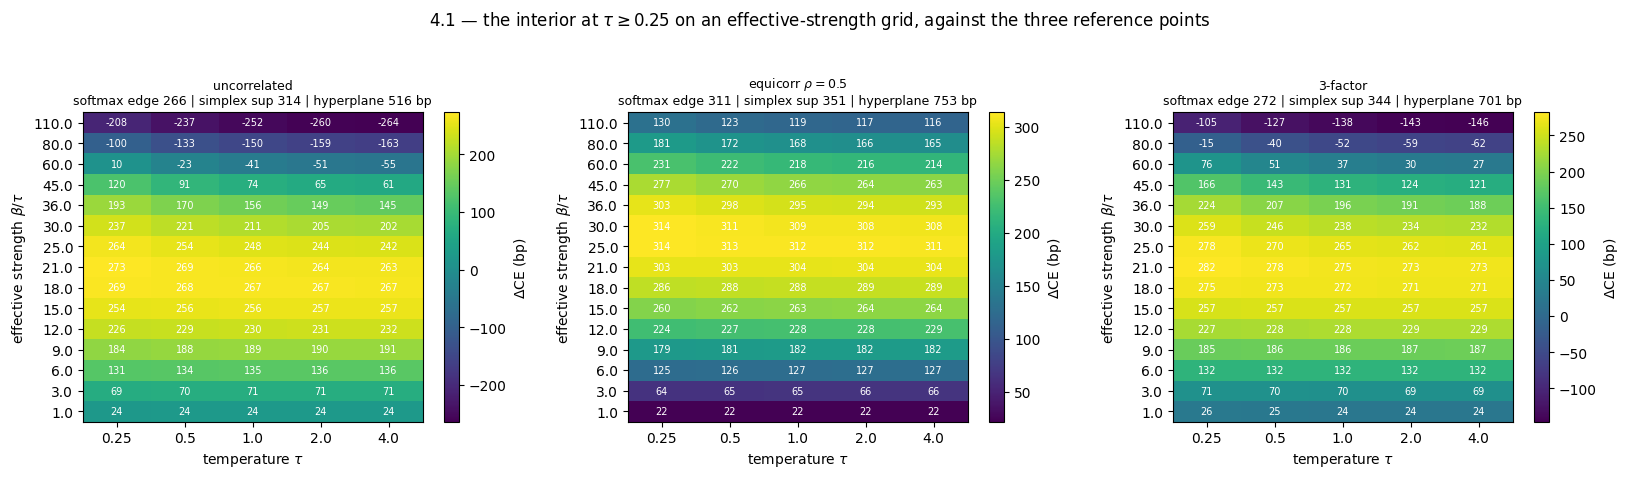

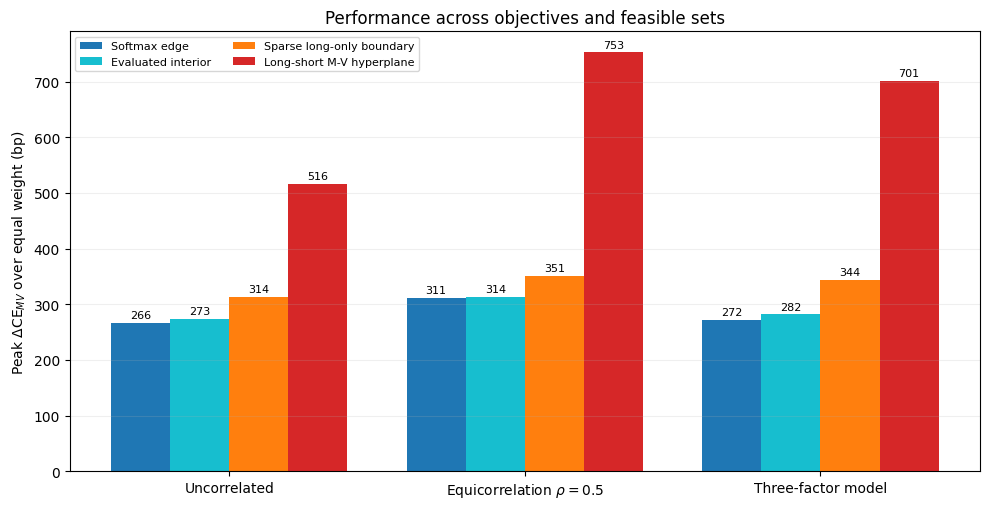

In [2]:
# ---- Experiment 4.1 ----

def erm_weights(s, beta, tau, Sigma_dot, iters=300, tol=1e-9, damp=0.5):
    w = np.full_like(s, 1.0 / N)
    for _ in range(iters):
        z = (beta * s - gamma * Sigma_dot(w)) / tau
        z -= z.max(axis=1, keepdims=True)
        w_new = np.exp(z); w_new /= w_new.sum(axis=1, keepdims=True)
        w_next = damp * w + (1 - damp) * w_new
        if np.abs(w_next - w).max() < tol: return w_next
        w = w_next
    return w

def proj_simplex(v):
    u = np.sort(v, axis=1)[:, ::-1]; css = np.cumsum(u, axis=1); j = np.arange(1, v.shape[1] + 1)
    r_ = v.shape[1] - 1 - np.argmax((u - (css - 1) / j > 0)[:, ::-1], axis=1)
    th = (css[np.arange(len(v)), r_] - 1) / (r_ + 1)
    return np.maximum(v - th[:, None], 0.0)

def simplex_sup(s, beta, Sigma_dot, var_eff, lip=None, Sig=None, max_iter=1000, tol=1e-9):
    # tau -> 0+ boundary of the long-only family: max beta s'w - (gamma/2) w'Sigma w over the
    # SIMPLEX. Closed form (water-filling) where Sigma acts as a scalar there; projected
    # gradient otherwise. Unlike the softmax it can set weights to exactly zero.
    if var_eff is not None:
        a = beta * s / (gamma * var_eff)
        lo, hi = a.min(axis=1) - 1.0, a.max(axis=1)
        for _ in range(60):
            mid = (lo + hi) / 2
            tot = np.maximum(a - mid[:, None], 0).sum(axis=1)
            hi = np.where(tot < 1, mid, hi); lo = np.where(tot < 1, lo, mid)
        w = np.maximum(a - ((lo + hi) / 2)[:, None], 0)
        return w / w.sum(axis=1, keepdims=True)
    if lip is None or Sig is None:
        raise ValueError("Projected gradient requires both lip and Sig.")
    required_lip = gamma * np.linalg.eigvalsh(Sig).max()
    if lip + 1e-12 < required_lip:
        raise ValueError(f"lip={lip:.6g} is below gamma*lambda_max(Sigma)={required_lip:.6g}")
    w = np.full_like(s, 1.0 / N)
    for _ in range(max_iter):
        w_next = proj_simplex(w + (1.8 / lip) * (beta * s - gamma * Sigma_dot(w)))
        if np.abs(w_next - w).max() < tol:
            return w_next
        w = w_next
    raise RuntimeError(f"Projected gradient did not converge in {max_iter} iterations.")

def hyperplane_mv(s, beta, Sig_inv):
    # tau = 0 EDGE: same objective on the budget hyperplane, sign unconstrained.
    # w = (beta/gamma) Sigma^{-1}(s - eta 1), eta fixed by 1'w = 1.
    one = np.ones(N); Sis = s @ Sig_inv.T; Si1 = Sig_inv @ one
    eta = (Sis.sum(axis=1) - gamma / beta) / (one @ Si1)
    return (beta / gamma) * (Sis - eta[:, None] * Si1)

s45 = mu + 0.05 * eps0
rho45 = 0.5
rng_c = np.random.default_rng(4242); z0 = rng_c.standard_normal((n_sims, 1))
R_eq = np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*(np.sqrt(rho45)*z0 + np.sqrt(1-rho45)*phi)) - 1.0
k_fac = 3
rng_f = np.random.default_rng(7)
B = np.empty((N, k_fac))
B[:, 0] = 0.45 + 0.15*rng_f.standard_normal(N); B[:, 1:] = 0.30*rng_f.standard_normal((N, k_fac-1))
nrm = np.sqrt((B**2).sum(axis=1)); tb = nrm > 0.95; B[tb] *= (0.95/nrm[tb])[:, None]
idio = 1.0 - (B**2).sum(axis=1)
F = rng_f.standard_normal((n_sims, k_fac))
R_f = np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*(F @ B.T + phi*np.sqrt(idio))) - 1.0

S_unc = sigma**2*dt*np.eye(N)
S_eq  = sigma**2*dt*((1-rho45)*np.eye(N) + rho45*np.ones((N, N)))
S_fac = sigma**2*dt*(B @ B.T + np.diag(idio))
lip_fac = gamma * np.linalg.eigvalsh(S_fac).max()
assert lip_fac + 1e-12 >= gamma * np.linalg.eigvalsh(S_fac).max()
cases = {   # returns, Sigma-dot, effective scalar variance on the simplex (or None), Lipschitz, Sigma
 'uncorrelated':              (R,    lambda w: sigma**2*dt*w, sigma**2*dt, None, S_unc),
 fr'equicorr $\rho={rho45}$': (R_eq, lambda w: sigma**2*dt*((1-rho45)*w + rho45*w.sum(axis=1, keepdims=True)),
                               sigma**2*dt*(1-rho45), None, S_eq),
 '3-factor':                  (R_f,  lambda w: sigma**2*dt*((w @ B) @ B.T + w*idio),
                               None, lip_fac, S_fac),
}

eff45  = [1.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 25.0, 30.0,
          36.0, 45.0, 60.0, 80.0, 110.0]        # effective strength beta/tau
tau45  = [0.25, 0.5, 1.0, 2.0, 4.0]     # only where the fixed point is verified to converge
rule = "-" * 92
res = {}
beta_sup_grid = np.unique(np.r_[np.linspace(0.05, 3.0, 40), 0.38])
beta_sup_grid_factor = np.unique(np.r_[np.linspace(0.05, 1.0, 40), 0.38])
for name, (R_c, Sdot, var_eff, lip, Sig) in cases.items():
    ce0 = ce_of(R_c.mean(axis=1))
    surf = np.empty((len(eff45), len(tau45))); thet = np.empty_like(surf)
    for i, e_ in enumerate(eff45):
        for j, t in enumerate(tau45):
            b = e_ * t                                   # beta rescaled to hold beta/tau fixed
            w = erm_weights(s45, b, t, Sdot)
            surf[i, j] = 1e4*(ce_of((w*R_c).sum(axis=1)) - ce0); thet[i, j] = theta_of(w).mean()
    edge = max(1e4*(ce_of((softmax_weights(s45, b)*R_c).sum(axis=1)) - ce0)
               for b in np.linspace(0, 400, 201))
    sup = (-np.inf, np.nan, np.nan)
    sup_grid = beta_sup_grid_factor if var_eff is None else beta_sup_grid
    for b in sup_grid:
        w = simplex_sup(s45, b, Sdot, var_eff, lip, Sig)
        d = 1e4*(ce_of((w*R_c).sum(axis=1)) - ce0)
        if d > sup[0]: sup = (d, b, (w < 1e-9).sum(axis=1).mean())
    Si = np.linalg.inv(Sig); hyp = (-np.inf, np.nan, np.nan)
    for b in np.linspace(0.02, 3.0, 60):
        w = hyperplane_mv(s45, b, Si)
        d = 1e4*(ce_of((w*R_c).sum(axis=1)) - ce0)
        if d > hyp[0]: hyp = (d, b, np.abs(np.minimum(w, 0)).sum(axis=1).mean())
    res[name] = (surf, edge, thet, sup, hyp)

print("Q1  LONG-ONLY (tau > 0): does the interior beat the softmax edge?")
print(rule)
print(f"{'Sigma':>20} {'softmax edge':>14} {'interior, tau>=0.25':>20} {'simplex sup (tau->0+)':>22} {'zeros':>8}")
print(rule)
for name, (surf, edge, thet, sup, hyp) in res.items():
    clean = name.replace('$','').replace('\\rho','rho')
    print(f"{clean:>20} {edge:>14.1f} {surf.max():>20.1f} {sup[0]:>22.1f} {sup[2]:>7.1f}/{N}")
print(rule)
print(f"{'gain over the softmax edge':>20} " + " " * 14
      + "".join(f"{surf.max()-edge:>+20.1f}{'':<0}" for _, (surf, edge, _, _, _) in [list(res.items())[0]])[:0]
      + "")
for name, (surf, edge, thet, sup, hyp) in res.items():
    clean = name.replace('$','').replace('\\rho','rho')
    print(f"{clean:>20}   interior {surf.max()-edge:+7.1f} bp      simplex sup {sup[0]-edge:+7.1f} bp")

print(f"\n\nQ2  RELEASING LONG-ONLY (tau = 0, budget hyperplane): what does shorting add?")
print(rule)
print(f"{'Sigma':>20} {'best in simplex':>16} {'hyperplane MV':>15} {'gain':>10} {'short expo':>12}")
print(rule)
for name, (surf, edge, thet, sup, hyp) in res.items():
    clean = name.replace('$','').replace('\\rho','rho')
    best_simplex = max(edge, surf.max(), sup[0])
    print(f"{clean:>20} {best_simplex:>16.1f} {hyp[0]:>15.1f} {hyp[0]-best_simplex:>+10.1f} {hyp[2]:>12.2f}")
print(rule)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
for ax, (name, (surf, edge, thet, sup, hyp)) in zip(axes, res.items()):
    im = ax.imshow(surf, origin='lower', aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(tau45))); ax.set_xticklabels(tau45)
    ax.set_yticks(range(len(eff45))); ax.set_yticklabels(eff45)
    ax.set_xlabel(r'temperature $\tau$'); ax.set_ylabel(r'effective strength $\beta/\tau$')
    ax.set_title(f'{name}\nsoftmax edge {edge:.0f} | simplex sup {sup[0]:.0f} | hyperplane {hyp[0]:.0f} bp',
                 fontsize=9)
    for i in range(len(eff45)):
        for j in range(len(tau45)):
            ax.annotate(f'{surf[i,j]:.0f}', (j, i), ha='center', va='center', fontsize=7, color='white')
    plt.colorbar(im, ax=ax, label=r'$\Delta$CE (bp)')
plt.suptitle(r'4.1 — the interior at $\tau \geq 0.25$ on an effective-strength grid, against the three reference points', y=1.03)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 5.2))
x = np.arange(len(res)); wd = 0.2
for off, key, lab, col in [(-1.5, 'edge', 'Softmax edge', 'tab:blue'),
                           (-0.5, 'int',  'Evaluated interior', 'tab:cyan'),
                           ( 0.5, 'sup',  'Sparse long-only boundary', 'tab:orange'),
                           ( 1.5, 'hyp',  'Long-short M-V hyperplane', 'tab:red')]:
    vals = [ {'edge': e, 'int': s.max(), 'sup': su[0], 'hyp': h[0]}[key]
             for (s, e, _, su, h) in res.values() ]
    bars = ax.bar(x + off*wd, vals, wd, label=lab, color=col)
    ax.bar_label(bars, labels=[f'{v:.0f}' for v in vals], padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(['Uncorrelated', r'Equicorrelation $\rho=0.5$', 'Three-factor model'])
ax.set_ylabel(r'Peak $\Delta\mathrm{CE}_{MV}$ over equal weight (bp)')
ax.set_title('Performance across objectives and feasible sets')
ax.grid(axis='y', alpha=0.2); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


In [3]:
# ---- Experiment 4.1, robustness: does the three-factor result depend on the draw of B? ----
# not heterogeneous variances. (Experiment 4.6 is the reverse case.)
def factor_block(seed):
    rf = np.random.default_rng(seed)
    Bs = np.empty((N, k_fac))
    Bs[:, 0]  = 0.45 + 0.15*rf.standard_normal(N)
    Bs[:, 1:] = 0.30*rf.standard_normal((N, k_fac-1))
    nm = np.sqrt((Bs**2).sum(axis=1)); big = nm > 0.95
    Bs[big] *= (0.95/nm[big])[:, None]
    idi = 1.0 - (Bs**2).sum(axis=1)
    Fs  = rf.standard_normal((n_sims, k_fac))
    return Bs, idi, Fs

b_seeds = [7, 1, 2, 3, 4]
bres = {}
for sd in b_seeds:
    Bs, idi, Fs = factor_block(sd)
    R_s   = np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*(Fs @ Bs.T + phi*np.sqrt(idi))) - 1.0
    Sdot_s = lambda w, Bs=Bs, idi=idi: sigma**2*dt*((w @ Bs) @ Bs.T + w*idi)
    Sig_s  = sigma**2*dt*(Bs @ Bs.T + np.diag(idi))
    lip_s  = gamma * np.linalg.eigvalsh(Sig_s).max()
    assert lip_s + 1e-12 >= gamma * np.linalg.eigvalsh(Sig_s).max()
    ce0_s  = ce_of(R_s.mean(axis=1))

    edge_s = max(1e4*(ce_of((softmax_weights(s45, b)*R_s).sum(axis=1)) - ce0_s)
                 for b in np.linspace(0, 400, 201))
    sup_s = (-np.inf, np.nan)
    for b in beta_sup_grid_factor:
        w = simplex_sup(s45, b, Sdot_s, None, lip_s, Sig_s)
        d = 1e4*(ce_of((w*R_s).sum(axis=1)) - ce0_s)
        if d > sup_s[0]: sup_s = (d, (w < 1e-9).sum(axis=1).mean())
    Si_s = np.linalg.inv(Sig_s); hyp_s = (-np.inf, np.nan)
    for b in np.linspace(0.02, 3.0, 60):
        w = hyperplane_mv(s45, b, Si_s)
        d = 1e4*(ce_of((w*R_s).sum(axis=1)) - ce0_s)
        if d > hyp_s[0]: hyp_s = (d, np.abs(np.minimum(w, 0)).sum(axis=1).mean())
    C_s = Bs @ Bs.T; np.fill_diagonal(C_s, 1.0); off_s = C_s[~np.eye(N, dtype=bool)]
    bres[sd] = (off_s.mean(), off_s.min(), off_s.max(), idi.mean(),
                edge_s, sup_s[0], sup_s[1], hyp_s[0], hyp_s[1])

print("Three-factor case, five independent draws of the factor block")
print("(everything else fixed: N, sigma, mu_bar, sigma_mu, sigma_eps, gamma_r = gamma, CRN seed 42)")
print(rule)
print(f"{'seed':>5} {'corr mean':>10} {'min':>7} {'max':>6} {'idio':>6} | {'edge':>7} {'sup':>7} "
      f"{'sup-edge':>9} {'zeros':>8} | {'hyper':>8} {'hyp/edge':>9} {'short':>6}")
print(rule)
for sd in b_seeds:
    cm, cmin, cmax, idm, e_, s_, z_, h_, sh_ = bres[sd]
    tag = "  <- the draw used above" if sd == 7 else ""
    print(f"{sd:>5} {cm:>10.2f} {cmin:>7.2f} {cmax:>6.2f} {idm:>6.2f} | {e_:>7.1f} {s_:>7.1f} "
          f"{s_-e_:>+9.1f} {z_:>5.1f}/{N} | {h_:>8.1f} {h_/e_:>9.2f} {sh_:>6.2f}{tag}")
print(rule)
arr = np.array([[bres[sd][4], bres[sd][5]-bres[sd][4], bres[sd][7], bres[sd][6], bres[sd][8]]
                for sd in b_seeds])
for j, lab in enumerate(['softmax edge', 'sup - edge', 'hyperplane', 'zeros', 'short exposure']):
    print(f"{lab:>16}:  min {arr[:, j].min():>8.1f}   max {arr[:, j].max():>8.1f}   "
          f"mean {arr[:, j].mean():>8.1f}   sd {arr[:, j].std(ddof=1):>6.1f}")
print(rule)
n_ = len(b_seeds)
print(f"orderings:  sup < edge in {sum(bres[s][5] < bres[s][4] for s in b_seeds)}/{n_} draws;  "
      f"hyperplane > edge in {sum(bres[s][7] > bres[s][4] for s in b_seeds)}/{n_};  "
      f"hyperplane > sup in {sum(bres[s][7] > bres[s][5] for s in b_seeds)}/{n_}.")
print(f"the sparse-boundary gain over the edge averages {arr[:, 1].mean():.1f} bp; "
      f"the main seed gives {arr[0, 1]:.1f} bp.")


Three-factor case, five independent draws of the factor block
(everything else fixed: N, sigma, mu_bar, sigma_mu, sigma_eps, gamma_r = gamma, CRN seed 42)
--------------------------------------------------------------------------------------------
 seed  corr mean     min    max   idio |    edge     sup  sup-edge    zeros |    hyper  hyp/edge  short
--------------------------------------------------------------------------------------------
    7       0.16   -0.21   0.57   0.66 |   272.5   344.4     +72.0  11.7/20 |    701.4      2.57   1.15  <- the draw used above
    1       0.20   -0.17   0.56   0.63 |   281.5   347.9     +66.4  12.1/20 |    722.2      2.57   1.30
    2       0.19   -0.47   0.53   0.59 |   272.6   369.5     +96.9  12.4/20 |    810.1      2.97   1.44
    3       0.17   -0.40   0.78   0.63 |   278.1   362.6     +84.5  12.0/20 |    825.3      2.97   1.48
    4       0.19   -0.27   0.57   0.63 |   276.7   368.0     +91.3  12.4/20 |    789.9      2.85   1.34
-----------

## Experiment 4.2 — Market-level signal

This experiment asks whether a portfolio map should respond to a signal about the overall market level when that signal contains no information about relative asset performance. In each replication,

$$
\mu_i=\bar\mu+M+\sigma_\mu z_i,\qquad M\sim\mathcal N(0,0.05^2),
$$

and the score supplied to the map is

$$
s(\lambda_M)=s+\lambda_M M\mathbf 1.
$$

The loading $\lambda_M$ records how strongly the investor acts on the observed market component. At $\lambda_M=0$ it is ignored, at $\lambda_M=1$ it is used at face value, and a negative loading acts against it.

The two preliminary maps respond differently. Softmax is shift-invariant, so adding the same amount to every score leaves its weights unchanged. The combination map is not shift-invariant: the common addition changes both $\Sigma^{-1}s$ and its random normaliser, and can therefore change the portfolio. Under full investment, however, every portfolio has the same direct exposure to the common return component. The signal is therefore real information about the market outcome, but it does not identify which assets should receive larger weights.

The code sweeps positive and negative values of $\lambda_M$ and re-optimises the combination strength $\alpha$ at every loading. A common intersection mask is used across the alternatives. A robustness panel repeats the comparison across calm, baseline, and turbulent volatility environments while keeping the construction of $M$ unchanged. The aim is to determine whether responding to a non-discriminating signal adds value or merely changes portfolio aggressiveness and normaliser stability.

softmax under market-signal loadings: max |weight difference| = 7.22e-16


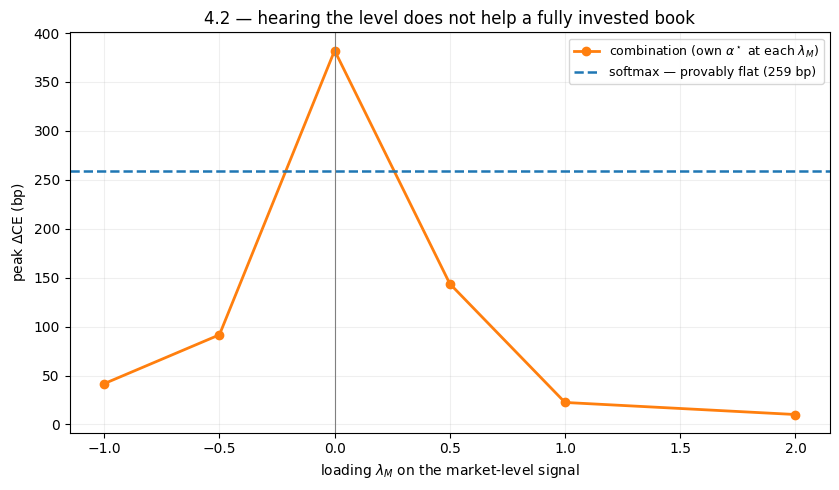


common comparison sample: 23398 retained, 6602 dropped
 lambda_M  comb peak dCE  alpha*
     -1.0           41.7    0.20
     -0.5           91.6    0.35
      0.0          382.1    1.40
      0.5          143.8    0.50
      1.0           22.5    0.18
      2.0           10.1    0.15


In [4]:
# ---- Experiment 4.2 ----
mu_M = mu + M_mkt                    # drifts with the common component
R_M  = np.exp((mu_M - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0
s_dr = mu + 0.05 * eps0              # baseline drift signal (cross-sectional part; noise as ever)

w0 = softmax_weights(s_dr, 21.0)
dev = max(np.abs(softmax_weights(s_dr + lam * M_mkt, 21.0) - w0).max() for lam in [0.5, 1.0, 2.0])
print(f"softmax under market-signal loadings: max |weight difference| = {dev:.2e}")

def normaliser_keep(scores, threshold=0.10):
    """Domain rule for the singular combination map, evaluated before comparisons."""
    ns = scores.sum(axis=1)
    return np.abs(ns) > threshold * np.median(np.abs(ns))

def comb_best_alpha(s_l, R_mat, keep, grid=np.linspace(0, 2, 81)):
    ns = s_l.sum(axis=1)
    w_s, R_m = s_l[keep] / ns[keep, None], R_mat[keep]
    p_eq, p_sig = R_m.mean(axis=1), (w_s * R_m).sum(axis=1)
    ce0 = ce_of(p_eq)
    best = (-np.inf, np.nan)
    for a in grid:
        d = 1e4 * (ce_of((1 - a) * p_eq + a * p_sig) - ce0)
        if d > best[0]: best = (d, a)
    return best

lamM_grid = [-1.0, -0.5, 0.0, 0.5, 1.0, 2.0]
scores44 = {lam: s_dr + lam * M_mkt for lam in lamM_grid}
keep44 = np.logical_and.reduce([normaliser_keep(x) for x in scores44.values()])
res44 = {lam: comb_best_alpha(scores44[lam], R_M, keep44) for lam in lamM_grid}
sfmx_pk, sfmx_b = best_beta(s_dr, R_M)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(lamM_grid, [res44[l][0] for l in lamM_grid], 'o-', lw=2, color='tab:orange',
        label=r'combination (own $\alpha^\star$ at each $\lambda_M$)')
ax.axhline(sfmx_pk, color='tab:blue', ls='--', lw=1.8,
           label=fr'softmax — provably flat ({sfmx_pk:.0f} bp)')
ax.axvline(0, color='grey', lw=0.8)
ax.set_xlabel(r'loading $\lambda_M$ on the market-level signal')
ax.set_ylabel(r'peak $\Delta$CE (bp)')
ax.set_title('4.2 — hearing the level does not help a fully invested book')
ax.grid(alpha=0.2); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"\ncommon comparison sample: {keep44.sum()} retained, {(~keep44).sum()} dropped")
print(f"{'lambda_M':>9} {'comb peak dCE':>14} {'alpha*':>7}")
for l in lamM_grid:
    d, a = res44[l]
    print(f"{l:>9} {d:>14.1f} {a:>7.2f}")


In [5]:
# ---- Experiment 4.2, robustness: the volatility ladder ----
sig_M42, sig_eps42 = 0.05, 0.05
lam42 = [0.0, 0.25, 0.5, 1.0, 2.0]
rule42 = "-" * 113

def comb_peak42(s_l, R_mat, keep, grid=np.linspace(0, 2, 81)):
    ns   = s_l.sum(axis=1)
    w_sig, R_k = s_l[keep]/ns[keep, None], R_mat[keep]
    c0 = ce_of(R_k.mean(axis=1)); best = -np.inf
    for a in grid:
        d = 1e4*(ce_of((((1.0-a)/N + a*w_sig)*R_k).sum(axis=1)) - c0)
        if d > best: best = d
    return best

print("Does the audibility result survive a change of market?   (mu_bar = 0.05 throughout;")
print("M carries the market year, so only the information axis is varied)")
print(rule42)
print(f"{'regime':>18}{'sig_mu':>8}{'sigma':>7}{'share':>8}{'SNR':>7} |"
      + "".join(f"{f'lam={l}':>9}" for l in lam42) + f" |{'common drops':>16}")
print(rule42)
res42r, devs42 = {}, []
for lab, smu, sg in VOL_LADDER:
    r_  = np.random.default_rng(42)
    mu_c = mu_bar + smu*r_.standard_normal((n_sims, N))
    e_c  = r_.standard_normal((n_sims, N)); p_c = r_.standard_normal((n_sims, N))
    R_c  = np.exp((mu_c + M_mkt - 0.5*sg**2)*dt + sg*np.sqrt(dt)*p_c) - 1.0
    s_c  = mu_c + sig_eps42*e_c                              # the signal never sees M
    w_ref = softmax_weights(s_c, 21.0)
    devs42.append(max(np.abs(softmax_weights(s_c + l*M_mkt, 21.0) - w_ref).max() for l in [0.5, 1.0, 2.0]))
    scores_c = [s_c + l*M_mkt for l in lam42]
    keep_c = np.logical_and.reduce([normaliser_keep(x) for x in scores_c])
    vals = [comb_peak42(x, R_c, keep_c) for x in scores_c]
    snr  = mu_bar/np.sqrt((smu**2 + sig_eps42**2)/N)
    sh   = smu**2*dt**2/(smu**2*dt**2 + sg**2*dt)
    res42r[lab] = vals
    print(f"{lab:>18}{smu:>8.2f}{sg:>7.2f}{sh:>8.1%}{snr:>7.2f} |"
          + "".join(f"{v:>9.1f}" for v in vals) + f" |{(~keep_c).sum():>16}")
print(rule42)
print(f"softmax: max |weight difference| over every regime and loading = {max(devs42):.0e} "
      f"(machine precision, as shift-invariance requires)")

A = np.array([res42r[lab] for lab, *_ in VOL_LADDER]); reg = A.max(axis=1, keepdims=True) - A
print(f"\nregret (bp) -- best achievable in that regime, minus what this loading delivers")
print(rule42)
print(f"{'regime':>18}" + "".join(f"{f'lam={l}':>10}" for l in lam42))
print(rule42)
for i, (lab, *_) in enumerate(VOL_LADDER):
    print(f"{lab:>18}" + "".join(f"{x:>10.1f}" for x in reg[i]))
print(rule42)
print(f"{'MAX regret':>18}" + "".join(f"{x:>10.1f}" for x in reg.max(axis=0)))
print(f"{'MEAN dCE':>18}" + "".join(f"{x:>10.1f}" for x in A.mean(axis=0)))
print(rule42)
print(f"lam_M = 0 is optimal in {int((A.argmax(axis=1) == 0).sum())} of {len(VOL_LADDER)} regimes, "
      f"with a maximum regret of {reg.max(axis=0)[0]:.1f} bp; a small positive loading wins in the two turbulent rows.")

print(f"\nthe stakes channel -- gross tilt |w - 1/N|_1 against the market year, at the baseline:")
print(rule42)
print(f"{'lam_M':>7}{'corr(M, tilt)':>15}{'mean tilt | M<0':>18}{'mean tilt | M>0':>18}")
print(rule42)
r_b = np.random.default_rng(42)
mu_b = REGIMES[0][1] + REGIMES[0][2]*r_b.standard_normal((n_sims, N))
s_b  = mu_b + sig_eps42*r_b.standard_normal((n_sims, N))
stakes_lam = [0.0, 0.25, 0.5, 1.0]
stakes_scores = [s_b + l*M_mkt for l in stakes_lam]
stakes_keep = np.logical_and.reduce([normaliser_keep(x) for x in stakes_scores])
for l, s_l in zip(stakes_lam, stakes_scores):
    ns = s_l.sum(axis=1)
    tilt = np.abs(s_l[stakes_keep]/ns[stakes_keep, None] - 1.0/N).sum(axis=1); Mk = M_mkt[stakes_keep, 0]
    print(f"{l:>7.2f}{np.corrcoef(Mk, tilt)[0, 1]:>15.3f}{tilt[Mk < 0].mean():>18.3f}{tilt[Mk > 0].mean():>18.3f}")
print(rule42)


Does the audibility result survive a change of market?   (mu_bar = 0.05 throughout;
M carries the market year, so only the information axis is varied)
-----------------------------------------------------------------------------------------------------------------
            regime  sig_mu  sigma   share    SNR |  lam=0.0 lam=0.25  lam=0.5  lam=1.0  lam=2.0 |    common drops
-----------------------------------------------------------------------------------------------------------------
         very calm    0.06   0.10   26.5%   2.86 |   1062.6    961.6    430.5     68.6     33.4 |            4470
              calm    0.07   0.15   17.9%   2.60 |    796.6    713.9    365.3     67.3     32.3 |            4691
  baseline (Ch. 3)    0.05   0.20    5.9%   3.16 |    376.1    340.5    174.3     27.8     13.3 |            4322
         turbulent    0.09   0.45    3.8%   2.17 |    182.1    188.7    122.9     27.6     13.2 |            5138
    very turbulent    0.11   0.65    2.8%   1.85 | 

## Experiment 4.3 — Measuring signal precision

The experiment gives signal precision a performance-based interpretation. It begins with a drift signal that observes a controlled fraction $b$ of the realised diffusion component,

$$
s_i(b)=\mu_i+b\sigma\sqrt{\Delta t}\,\phi_i+\sigma_\varepsilon\xi_i,
$$

where $b=0$ is the ordinary noisy drift signal and increasing $b$ provides more information about the component of returns treated as unpredictable by the baseline GBM filtration. The share of one-period cross-sectional return variation addressed by the signal is

$$
q(b)=\frac{\sigma_\mu^2\Delta t^2+b^2\sigma^2\Delta t}{\sigma_\mu^2\Delta t^2+\sigma^2\Delta t}.
$$

Part (a) varies $b\in\{0,0.1,0.25,0.5,1\}$ and re-optimises softmax strength. At $b=1$ the signal observes the complete diffusion component in the common-volatility setting and becomes an oracle for the realised cross-sectional ranking. The analysis is restricted to the long-only softmax map so that this outcome-informed information cannot be scaled through unrestricted long--short positions.

Part (b) introduces a second benchmark. Let $\mathcal K_k$ be the set of the $k$ assets with the highest realised returns and define $s_i^{(k)}=\mathbf 1\{i\in\mathcal K_k\}$. This top-$k$ signal reveals membership of the winning set but not exact returns or the ranking within that set. A smaller $k$ is more informative. At finite $\beta$, all assets retain positive weight; as $\beta\to\infty$, the portfolio converges to equal weight over the selected set. These signals deliberately use realised outcomes and are included only as a measurement benchmark.

Part (c) evaluates the complete integer top-$k$ ladder and uses linear interpolation to find the equivalent $k^*$ whose peak CE matches a given drift-based signal. This provides a tangible exchange rate: the value of a drift signal can be described by the size of the realised winner set that would deliver the same performance.

The remaining checks examine whether this exchange rate is specific to the baseline calibration. They distinguish the total return scale

$$
\Omega=\sqrt{\sigma_\mu^2\Delta t^2+\sigma^2\Delta t}
$$

from the predictable drift share $q(0)$, rather than changing both unintentionally. The fitted one- and two-variable exchange-rate rules are compared across a grid of drift dispersions and volatilities and then applied to the market-regime calibrations. These checks assess whether signal value is mainly explained by predictable share, return scale, or the common bull--bear level.

variance budget at the baseline: drift 5.9%, diffusion component 94.1%
total cross-sectional spread Omega = 0.2062
clean drift signal: 435.3 bp at beta* = 31

(a) THE INFORMATION DIAL
------------------------------------------------------------------------------
     b component seen     b^2  share added  total share   peak dCE   beta*
------------------------------------------------------------------------------
   0.0         0%   0.000        0.0%         5.9%      266.1      18
   0.1        10%   0.010        0.9%         6.8%      988.2      32
  0.25        25%   0.062        5.9%        11.8%     2081.1      58
   0.5        50%   0.250       23.5%        29.4%     3215.9     129
   1.0       100%   1.000       94.1%       100.0%     3810.2     284
------------------------------------------------------------------------------

(b) TOP-k LADDER
------------------------------------------------------------------------------
   k  of universe  names excluded   peak dCE   x clean  t

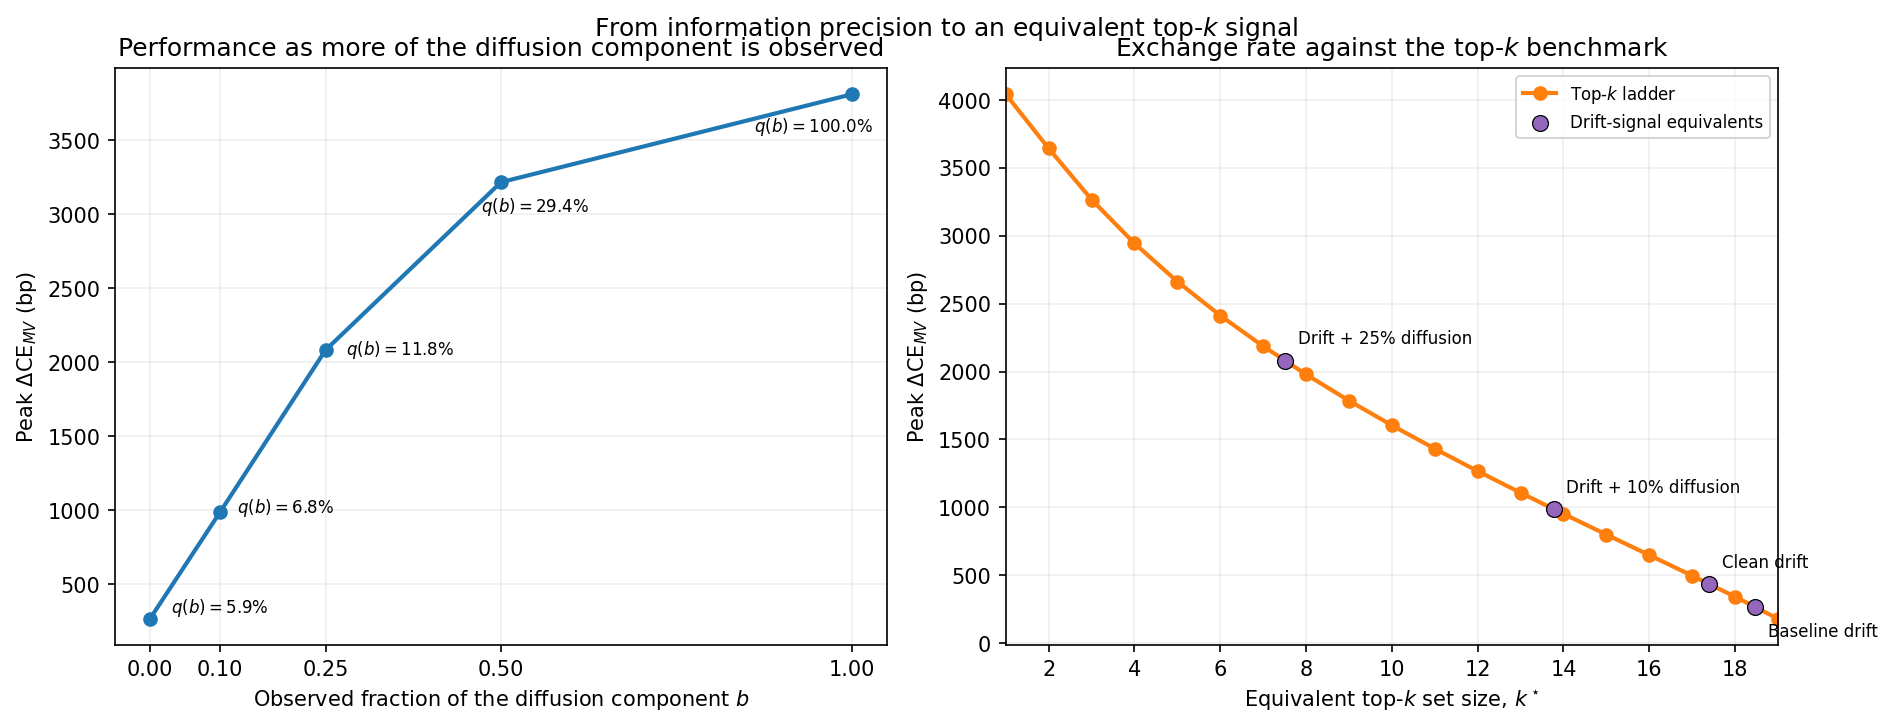

In [12]:
# ---- Experiment 4.3 ----
# (a) the information dial     (b) top-k ladder              (c) exchange rate at baseline
# (d) falsification test       (e) the (Omega, share) sweep
# (f) the exchange rate in units of names      (g) four market regimes
sigma_eps_base = 0.05
diffusion_component = sigma * np.sqrt(dt) * phi
drift_share = sigma_mu**2 * dt**2 / (sigma_mu**2 * dt**2 + sigma**2 * dt)
Omega_base  = np.sqrt(sigma_mu**2 * dt**2 + sigma**2 * dt)
share = lambda b: (sigma_mu**2 * dt**2 + b**2 * sigma**2 * dt) / (sigma_mu**2 * dt**2 + sigma**2 * dt)
rule = "-" * 78

# ---------------- (a) the information dial ----------------
b_grid   = [0.0, 0.1, 0.25, 0.5, 1.0]
leak_grids = {b: (np.arange(0.0, 401.0, 1.0) if b >= 0.5 else beta_grid) for b in b_grid}
res_leak = {b: best_beta(mu + b * diffusion_component + sigma_eps_base * eps0, R, grid=leak_grids[b]) for b in b_grid}
clean_pk, clean_bstar = best_beta(mu, R, grid=np.arange(0.0, 121.0, 1.0))

print(f"variance budget at the baseline: drift {drift_share:.1%}, diffusion component {1-drift_share:.1%}")
print(f"total cross-sectional spread Omega = {Omega_base:.4f}")
print(f"clean drift signal: {clean_pk:.1f} bp at beta* = {clean_bstar:.0f}\n")
print("(a) THE INFORMATION DIAL");  print(rule)
print(f"{'b':>6} {'component seen':>14} {'b^2':>7} {'share added':>12} {'total share':>12} {'peak dCE':>10} {'beta*':>7}")
print(rule)
for b in b_grid:
    print(f"{b:>6} {b:>10.0%} {b**2:>7.3f} {b**2*(1-drift_share):>11.1%} {share(b):>12.1%} "
          f"{res_leak[b][0]:>10.1f} {res_leak[b][1]:>7.0f}")
print(rule)

# ---------------- (b) the top-k ladder ----------------
order     = np.argsort(R, axis=1)
bgrid_ind = np.linspace(0.0, 12.0, 61)
def topk_signal(order_mat, k, like):
    ind = np.zeros_like(like); np.put_along_axis(ind, order_mat[:, -k:], 1.0, axis=1); return ind

k_show = [15, 10, 5, 2, 1]
res_topk, theta_at_opt = {}, {}
for k in k_show:
    ind = topk_signal(order, k, R)
    res_topk[k] = best_beta(ind, R, grid=bgrid_ind)
    theta_at_opt[k] = theta_of(softmax_weights(ind, res_topk[k][1])).mean()

print("\n(b) TOP-k LADDER");  print(rule)
print(f"{'k':>4} {'of universe':>12} {'names excluded':>15} {'peak dCE':>10} {'x clean':>9} {'theta@opt':>10} {'theta_max':>10}")
print(rule)
for k in k_show:
    print(f"{k:>4} {k/N:>12.0%} {N-k:>15} {res_topk[k][0]:>10.1f} {res_topk[k][0]/clean_pk:>9.1f} "
          f"{theta_at_opt[k]:>10.3f} {1-np.log(k)/np.log(N):>10.3f}")
print(rule)

# ---------------- (c) exchange rate, baseline parameters only ----------------
ks_full = list(range(19, 0, -1))
tk_full = np.array([best_beta(topk_signal(order, k, R), R, grid=bgrid_ind)[0] for k in ks_full])
ka_full = np.array(ks_full, float)
def k_equiv(v):
    return float(np.interp(v, tk_full, ka_full)) if v >= tk_full[0] else np.nan

print(f"\n(c) EXCHANGE RATE at the baseline drift share of {drift_share:.1%}: "
      f"what is a drift signal worth, in names excluded?")
print("    (parts (e) and (f) show how this changes as the share and the scale move)")
print(rule)
print(f"{'signal':>34} {'peak dCE':>10} {'equivalent to':>26}")
print(rule)
for lab, s_, gr in [('clean drift (sigma_eps = 0)',      mu,                                np.arange(0.0,201.0,1.0)),
                    ('drift at baseline noise 0.05',     mu + 0.05*eps0,                    beta_grid),
                    ('drift + 10% diffusion',            mu + 0.10*diffusion_component + 0.05*eps0, np.linspace(0,200,101)),
                    ('drift + 25% diffusion',            mu + 0.25*diffusion_component + 0.05*eps0, np.linspace(0,300,151))]:
    v = best_beta(s_, R, grid=gr)[0]; ke = k_equiv(v)
    print(f"{lab:>34} {v:>10.1f} {f'top-{ke:.1f}, i.e. naming {N-ke:.1f} names to avoid':>26}")
print(rule)
d_ = np.diff(tk_full)

# ---------------- (d) falsification test ----------------
rng_x  = np.random.default_rng(2026)
win    = rng_x.integers(0, N, size=n_sims)
mu_x   = np.full((n_sims, N), -0.10); mu_x[np.arange(n_sims), win] = +0.40
R_x    = np.exp((mu_x - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*phi) - 1.0
share_x = mu_x.var(axis=1).mean()*dt**2 / (mu_x.var(axis=1).mean()*dt**2 + sigma**2*dt)
order_x = np.argsort(R_x, axis=1)
clean_x = best_beta(mu_x, R_x, np.linspace(0, 60, 121))[0]
topk_x  = {k: best_beta(topk_signal(order_x, k, R_x), R_x, bgrid_ind)[0] for k in [10, 5, 2]}

print("\n(d) FALSIFICATION TEST: an extreme cross-section, built so the drift SHOULD win")
print(f"    1 name at mu = +0.40, the rest 19 at -0.10")
print(rule)
print(f"{'':<22}{'EXTREME  (drift share ' + f'{share_x:.0%})':>26}{'BASELINE  (drift share ' + f'{drift_share:.0%})':>28}")
print(f"{'signal':<22}{'dCE':>12}{'vs drift':>14}{'dCE':>14}{'vs drift':>14}")
print(rule)
print(f"{'clean drift':<22}{clean_x:>12.0f}{1.00:>14.2f}{clean_pk:>14.0f}{1.00:>14.2f}")
for k in [10, 5, 2]:
    print(f"{f'top-{k}':<22}{topk_x[k]:>12.0f}{topk_x[k]/clean_x:>14.2f}"
          f"{res_topk[k][0]:>14.0f}{res_topk[k][0]/clean_pk:>14.2f}")
print(rule)

# ---------------- (e) the (Omega, share) sweep ----------------
def lab_world(sig_mu_c, sigma_c, mu_bar_c=None, seed=42):
    """A self-contained market: its own CRN, drift dispersion and diffusion scale."""
    mb = mu_bar if mu_bar_c is None else mu_bar_c
    r  = np.random.default_rng(seed)
    m  = mb + sig_mu_c * r.standard_normal((n_sims, N))
    p  = r.standard_normal((n_sims, N))
    Rc = np.exp((m - 0.5*sigma_c**2)*dt + sigma_c*np.sqrt(dt)*p) - 1.0
    return m, Rc, np.argsort(Rc, axis=1)

def value_of(m, Rc, oc, sig_mu_c, ks=(10, 5, 2)):
    """Peak dCE for the clean drift signal and for each top-k, within one market."""
    hi = max(60.0, 6.0 / max(sig_mu_c, 1e-6))
    cl = best_beta(m, Rc, np.linspace(0, hi, 81))[0]
    tk = {k: best_beta(topk_signal(oc, k, Rc), Rc, bgrid_ind)[0] for k in ks}
    return cl, tk

print("\n(e) THE (Omega, share) SWEEP: information content at a FIXED risk scale")
print(f"    Omega held at the baseline {Omega_base:.4f}; only the predictable fraction varies")
print(rule)
print(f"{'share':>8} {'sigma_mu':>9} {'sigma':>7} {'clean drift':>12} {'top-10':>9} {'top-5':>9} {'drift/top-10':>13}")
print(rule)
share_grid = [0.038, drift_share, 0.10, 0.179, 0.20, 0.35, 0.50, 0.75]
sweep = {}
for sh in share_grid:
    smu_c, sg_c = Omega_base*np.sqrt(sh), Omega_base*np.sqrt(1-sh)
    m, Rc, oc = lab_world(smu_c, sg_c)
    cl, tk = value_of(m, Rc, oc, smu_c)
    sweep[sh] = (smu_c, sg_c, cl, tk[10], tk[5])
    tag = {0.038: '  <- turbulent', 0.179: '  <- calm'}.get(round(sh, 3), '')
    print(f"{sh:>8.1%} {smu_c:>9.3f} {sg_c:>7.3f} {cl:>12.0f} {tk[10]:>9.0f} {tk[5]:>9.0f} {cl/tk[10]:>13.2f}{tag}")
print(rule)
shs   = np.array(share_grid)
rat10 = np.array([sweep[s][2]/sweep[s][3] for s in share_grid])
rat5  = np.array([sweep[s][2]/sweep[s][4] for s in share_grid])
x10, x5 = np.interp(1.0, rat10, shs), np.interp(1.0, rat5, shs)

# ---------------- (f) the exchange rate in units of names ----------------
ks_ladder = [1, 2, 3, 5, 7, 10, 13, 16, 19]
mkts_i = [(0.025, 0.20), (0.025, 0.15), (0.05, 0.30), (0.05, 0.20), (0.05, 0.15), (0.10, 0.30),
          (0.10, 0.20), (0.10, 0.15), (0.20, 0.30), (0.20, 0.20), (0.20, 0.15)]
print("\n(f) THE EXCHANGE RATE IN UNITS OF NAMES: how many names is a drift signal worth?")
print(rule)
print(f"{'sigma_mu':>9} {'sigma':>7} {'share':>8} {'Omega':>7} {'drift dCE':>11} {'k*':>7} {'names to exclude':>18}")
print(rule)
rows_i = []
for smu_c, sg_c in mkts_i:
    m_c, R_c, o_c = lab_world(smu_c, sg_c)
    lad = np.array([best_beta(topk_signal(o_c, k, R_c), R_c, bgrid_ind)[0] for k in ks_ladder])
    dr  = best_beta(m_c, R_c, np.linspace(0, max(60.0, 6.0/smu_c), 81))[0]
    sh_ = smu_c**2*dt**2/(smu_c**2*dt**2 + sg_c**2*dt); Om_ = np.sqrt(smu_c**2*dt**2 + sg_c**2*dt)
    ka  = np.array(ks_ladder, float)
    # the ladder decreases in k, so invert on the reversed arrays; NaN where the drift signal
    # falls outside the ladder's range and the exchange rate is simply not defined
    kst = float(np.interp(dr, lad[::-1], ka[::-1])) if lad.min() <= dr <= lad.max() else np.nan
    rows_i.append((smu_c, sg_c, sh_, Om_, dr, kst))
    ks_txt = f"{kst:>7.2f}" if kst == kst else f"{'--':>7}"
    ex_txt = f"{N-kst:>18.2f}" if kst == kst else f"{'not priceable':>18}"
    print(f"{smu_c:>9.3f} {sg_c:>7.2f} {sh_:>8.1%} {Om_:>7.3f} {dr:>11.0f}{ks_txt}{ex_txt}")
print(rule)

ok  = [r for r in rows_i if r[5] == r[5]]
shv = np.array([r[2] for r in ok]); Omv = np.array([r[3] for r in ok])
yv  = np.log(N - np.array([r[5] for r in ok]))
X1  = np.c_[np.ones(len(ok)), np.log(shv)]
X2  = np.c_[np.ones(len(ok)), np.log(shv), np.log(Omv)]
b1  = np.linalg.lstsq(X1, yv, rcond=None)[0]; r1 = 1 - ((yv - X1@b1).var()/yv.var())
b2  = np.linalg.lstsq(X2, yv, rcond=None)[0]; r2 = 1 - ((yv - X2@b2).var()/yv.var())
print(f"    share only : N - k* = {np.exp(b1[0]):>5.1f} share^{b1[1]:.2f}"
      f"                 R^2 = {r1:.3f}")
print(f"    + the scale: N - k* = {np.exp(b2[0]):>5.1f} share^{b2[1]:.2f} Omega^{b2[2]:.2f}"
      f"   R^2 = {r2:.3f}")
print(f"\n{'share':>8} {'predicted N-k*':>16} {'actual':>9} {'error':>8}")
for smu_c, sg_c, sh_, Om_, dr, kst in ok:
    pr = np.exp(b1[0])*sh_**b1[1]
    print(f"{sh_:>8.1%} {pr:>16.2f} {N-kst:>9.2f} {pr-(N-kst):>8.2f}")
print(rule)
print(f"\n    LEVEL versus VOLATILITY: which market axis moves the exchange rate?")
print(rule)
print(f"{'regime':>20} {'mu_bar':>8} {'sig_mu':>7} {'sigma':>6} {'share':>7} {'Omega_R':>9} "
      f"{'k*':>7} {'names to exclude':>18}")
print(rule)
cells_h = {}
for vlab, smu_c, sg_c in [('calm', 0.07, 0.15), ('turbulent', 0.09, 0.45)]:
    for mlab, mb in [('bull', 0.24), ('bear', -0.33)]:
        m_c, R_c, o_c = lab_world(smu_c, sg_c, mu_bar_c=mb)
        lad = np.array([best_beta(topk_signal(o_c, k, R_c), R_c, bgrid_ind)[0] for k in ks_ladder])
        dr  = best_beta(m_c, R_c, np.linspace(0, max(60.0, 6.0/smu_c), 81))[0]
        ka  = np.array(ks_ladder, float)
        kst = float(np.interp(dr, lad[::-1], ka[::-1]))
        sh_ = smu_c**2*dt**2/(smu_c**2*dt**2 + sg_c**2*dt)
        cells_h[(mlab, vlab)] = N - kst
        print(f"{mlab + ', ' + vlab:>20} {mb:>+8.2f} {smu_c:>7.2f} {sg_c:>6.2f} {sh_:>7.1%} "
              f"{R_c.std(axis=1).mean():>9.3f} {kst:>7.2f} {N-kst:>18.2f}")
print(rule)
lvl = [cells_h[('bear', v)]/cells_h[('bull', v)] for v in ('calm', 'turbulent')]
vol = [cells_h[(m, 'calm')]/cells_h[(m, 'turbulent')] for m in ('bull', 'bear')]
print(f"{'LEVEL effect  (bull -> bear, share unchanged)':>52}: "
      f"x{lvl[0]:.2f} in calm, x{lvl[1]:.2f} in turbulent")
print(f"{'VOLATILITY effect  (calm -> turbulent)':>52}: "
      f"x{vol[0]:.2f} in bull, x{vol[1]:.2f} in bear")
print(f"{'ratio of the two, in log terms':>52}: "
      f"{np.mean(np.log(vol))/np.mean(np.log(lvl)):.1f}x")
print(rule)

# ---------------- (g) the canonical market regimes ----------------
print("\n(g) THE CANONICAL MARKET REGIMES")
print("    bull/bear sets mu_bar; calm/turbulent sets (sigma_mu, sigma) jointly, both countercyclical.")
print(rule)
print(f"{'regime':>18} {'mu_bar':>7} {'sg_mu':>6} {'sigma':>6} {'share':>7} {'Omega':>7} {'Omega_R':>8} "
      f"{'drift':>7} {'top-10':>7} {'ratio':>6}")
print(rule)
reg = {}
for lab, mb, smu_c, sg_c in REGIMES:          # the canonical set, defined once in the setup cell
    m, Rc, oc = lab_world(smu_c, sg_c, mu_bar_c=mb)
    cl, tk = value_of(m, Rc, oc, smu_c)
    sh  = smu_c**2*dt**2/(smu_c**2*dt**2 + sg_c**2*dt)
    Om  = np.sqrt(smu_c**2*dt**2 + sg_c**2*dt)
    OmR = Rc.std(axis=1).mean()
    reg[lab] = (sh, Om, OmR, cl, tk[10])
    print(f"{lab:>18} {mb:>+7.2f} {smu_c:>6.2f} {sg_c:>6.2f} {sh:>7.1%} {Om:>7.3f} {OmR:>8.3f} "
          f"{cl:>7.0f} {tk[10]:>7.0f} {cl/tk[10]:>6.2f}")
print(rule)

# ---------------- report-facing figure ----------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), dpi=150, constrained_layout=True)

ax = axes[0]
b_ce = [res_leak[b][0] for b in b_grid]
ax.plot(b_grid, b_ce, 'o-', lw=2, color='tab:blue')
label_offsets = {
    0.0:  (10, 0, 'left',  'bottom'),
    0.1:  (8, -3, 'left', 'bottom'),
    0.25: (10, -5, 'left', 'bottom'),
    0.5:  (42, -17, 'right', 'bottom'),
    1.0:  (10, -10, 'right', 'top'),
}
for b, ce in zip(b_grid, b_ce):
    dx, dy, ha, va = label_offsets[b]
    ax.annotate(fr'$q(b)={100*share(b):.1f}\%$', (b, ce), textcoords='offset points',
                xytext=(dx, dy), ha=ha, va=va, fontsize=8)
ax.set_xticks(b_grid)
ax.set_xlabel(r'Observed fraction of the diffusion component $b$')
ax.set_ylabel(r'Peak $\Delta\mathrm{CE}_{MV}$ (bp)')
ax.set_title('Performance as more of the diffusion component is observed')
ax.grid(alpha=0.2)

equiv_specs = [
    ('Clean drift', mu, np.arange(0.0, 201.0, 1.0)),
    ('Baseline drift', mu + 0.05*eps0, beta_grid),
    ('Drift + 10% diffusion', mu + 0.10*diffusion_component + 0.05*eps0, np.linspace(0, 200, 101)),
    ('Drift + 25% diffusion', mu + 0.25*diffusion_component + 0.05*eps0, np.linspace(0, 300, 151)),
]
equiv_points = []
for lab, sig_, grid_ in equiv_specs:
    ce = best_beta(sig_, R, grid=grid_)[0]
    equiv_points.append((lab, k_equiv(ce), ce))

ax = axes[1]
ax.plot(ka_full, tk_full, 'o-', lw=2, color='tab:orange', label=r'Top-$k$ ladder')
for j, (lab, excluded, ce) in enumerate(equiv_points):
    ax.scatter(excluded, ce, s=58, color='tab:purple', edgecolor='black', linewidth=0.6,
               zorder=3, label='Drift-signal equivalents' if j == 0 else None)
    dy = 8 if lab != 'Baseline drift' else -14
    ax.annotate(lab, (excluded, ce), textcoords='offset points', xytext=(6, dy), fontsize=8)
ax.set_xlim(1, N-1)
ax.set_xlabel(r'Equivalent top-$k$ set size, $k^\star$')
ax.set_ylabel(r'Peak $\Delta\mathrm{CE}_{MV}$ (bp)')
ax.set_title(r'Exchange rate against the top-$k$ benchmark')
ax.grid(alpha=0.2); ax.legend(fontsize=8)

plt.suptitle(r'From information precision to an equivalent top-$k$ signal', y=1.02)
plt.show()


## Experiment 4.4 — Comparing signal forms

This experiment holds the noisy drift information fixed and changes only how it is presented to the softmax map. Four representations are compared:

1. **Cardinal scores:** the numerical drift-signal values are used directly.
2. **Naive ranks:** the assets receive equally spaced scores according to their signal ranking.
3. **Gaussian-inferred ranks:** ranks are mapped to expected Gaussian order statistics using Blom's approximation.
4. **Median split:** the map observes only whether an asset lies above or below the cross-sectional signal median.

The cardinal signal contains both ordering and numerical gaps. Naive ranks retain the ordering but impose an equal gap between adjacent ranks, so the resulting softmax weights form a geometric progression. Gaussian-inferred ranks restore the spacing expected from a Gaussian cross-section without recovering the realised cardinal gaps. The median split discards both within-group rankings and magnitudes; with $N=20$, it divides the assets into two groups of ten.

Strength is re-optimised separately for every representation because their numerical scales differ. Consequently, the reported optimal $\beta$ values are not directly comparable across formats; the relevant comparison is their peak M--V CE. For a two-level score, affine changes in the two levels are absorbed by softmax shift-invariance and the optimised strength, so alternative two-level encodings describe the same portfolio path.

The baseline comparison is repeated across the market regimes. A further grid varies drift share and signal reliability while holding the common volatility fixed. These checks distinguish whether any rank advantage comes from removing signal noise, from changing the spacing of scores before exponentiation, or from the market calibration itself. Unlike the top-$k$ benchmark in Experiment 4.3, all groups and ranks here are formed from the noisy drift signal rather than realised returns.

two-level check: max |weight difference| naive vs inference binary signal = 0.00e+00



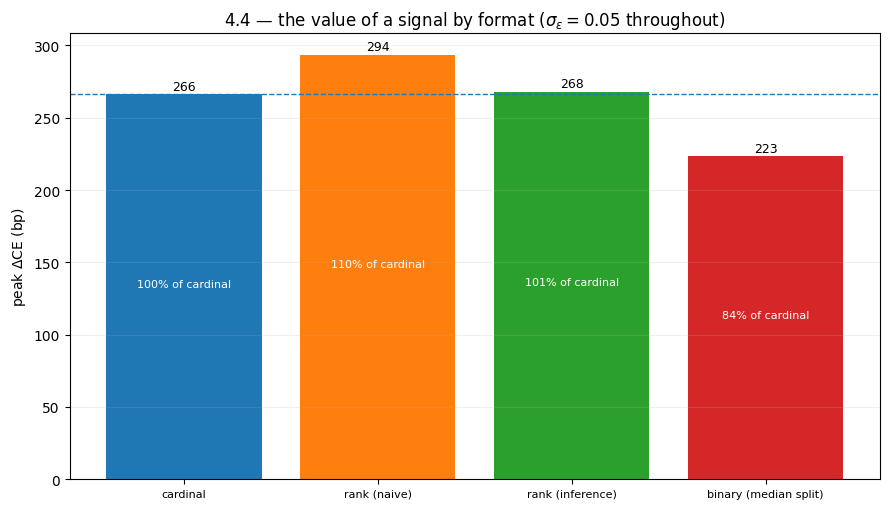

                    format  peak dCE (bp)   beta*  % of cardinal
                  cardinal          266.1   18.00         100.0%
              rank (naive)          293.7    0.34         110.4%
          rank (inference)          268.1    1.40         100.8%
     binary (median split)          223.3   36.00          83.9%


In [7]:
# ---- Experiment 4.4 ----
s43 = mu + 0.05 * eps0
ranks = s43.argsort(axis=1).argsort(axis=1)          # 0 (lowest) .. N-1 (highest), per draw

blom = norm.ppf((np.arange(1, N + 1) - 0.375) / (N + 0.25))

formats = {}
formats['cardinal']       = s43
formats['rank (naive)']   = ranks.astype(float)               # equal spacing
formats['rank (inference)'] = blom[ranks]                     # order-statistic spacing
formats['binary (median split)'] = (ranks >= N // 2).astype(float)      # above/below the cross-sectional median

lvl_hi, lvl_lo = blom[N//2:].mean(), blom[:N//2].mean()
sign_inf = np.where(formats['binary (median split)'] > 0, lvl_hi, lvl_lo)
w_a = softmax_weights(formats['binary (median split)'], 6.0)
w_b = softmax_weights(sign_inf, 6.0 / (lvl_hi - lvl_lo))
print(f"two-level check: max |weight difference| naive vs inference binary signal = "
      f"{np.abs(w_a - w_b).max():.2e}\n")

bg43 = {'cardinal': beta_grid, 'rank (naive)': np.linspace(0, 1.2, 61),
        'rank (inference)': np.linspace(0, 6, 61), 'binary (median split)': np.linspace(0, 40, 81)}
res43 = {name: best_beta(sig, R, grid=bg43[name]) for name, sig in formats.items()}

names = list(formats)
fig, ax = plt.subplots(figsize=(9, 5.2))
vals = [res43[n][0] for n in names]
bars = ax.bar(range(len(names)), vals,
              color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
ax.axhline(res43['cardinal'][0], color='tab:blue', ls='--', lw=1)
for i, n in enumerate(names):
    ax.annotate(f"{vals[i]:.0f}", (i, vals[i] + 3), ha='center', fontsize=9)
    ax.annotate(f"{vals[i]/vals[0]:.0%} of cardinal", (i, vals[i] / 2), ha='center',
                fontsize=8, color='white')
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel(r'peak $\Delta$CE (bp)')
ax.set_title(r'4.4 — the value of a signal by format ($\sigma_\varepsilon = 0.05$ throughout)')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.show()

print(f"{'format':>26} {'peak dCE (bp)':>14} {'beta*':>7} {'% of cardinal':>14}")
for n in names:
    print(f"{n:>26} {res43[n][0]:>14.1f} {res43[n][1]:>7.2f} {res43[n][0]/res43['cardinal'][0]:>14.1%}")


In [8]:
# ---- Experiment 4.4, robustness ----
# (a) the canonical market regimes; (b) what governs the rank advantage
fmt_names = ['cardinal', 'rank (naive)', 'rank (inference)', 'binary (median split)']
print("(a) FORMAT VALUE ACROSS THE CANONICAL REGIMES")
print("      (sigma_eps = sigma_mu, so kappa = 0.5 in every regime)")
print(rule)
print(f"{'regime':>18} {'share':>7} | {'cardinal':>9} {'rank naive':>11} {'rank infer':>11} "
      f"{'binary':>10} | {'naive':>7} {'infer':>7} {'binary':>8}")
print(rule)
res44r = []
for lab, mb, smu_c, sg_c in REGIMES:
    mu_c, s_c, R_c, sh_ = regime_market(mb, smu_c, sg_c)
    rk_c = s_c.argsort(axis=1).argsort(axis=1)
    f_c = {'cardinal':              (s_c,                          np.linspace(0, max(120.0, 6.0/smu_c), 121)),
           'rank (naive)':          (rk_c.astype(float),           np.linspace(0, 1.2, 61)),
           'rank (inference)':      (blom[rk_c],                   np.linspace(0, 6, 61)),
           'binary (median split)': ((rk_c >= N//2).astype(float), np.linspace(0, 40, 81))}
    v = {k: best_beta(sig, R_c, grid=g)[0] for k, (sig, g) in f_c.items()}
    res44r.append((lab, sh_, v))
    print(f"{lab:>18} {sh_:>7.1%} | {v['cardinal']:>9.1f} {v['rank (naive)']:>11.1f} "
          f"{v['rank (inference)']:>11.1f} {v['binary (median split)']:>10.1f} | "
          f"{v['rank (naive)']/v['cardinal']:>7.0%} {v['rank (inference)']/v['cardinal']:>7.0%} "
          f"{v['binary (median split)']/v['cardinal']:>8.0%}")
print(rule)
nn = len(res44r)
print(f"orderings:  rank (naive) >= cardinal in "
      f"{sum(v['rank (naive)'] >= v['cardinal'] for _,_,v in res44r)}/{nn} regimes;  "
      f"rank (inference) < cardinal in {sum(v['rank (inference)'] < v['cardinal'] for _,_,v in res44r)}/{nn};  "
      f"binary < cardinal in {sum(v['binary (median split)'] < v['cardinal'] for _,_,v in res44r)}/{nn}.")
for k in fmt_names[1:]:
    rr = np.array([v[k]/v['cardinal'] for _,_,v in res44r])
    print(f"{k:>22} as a share of cardinal: min {rr.min():.0%}  max {rr.max():.0%}  mean {rr.mean():.0%}")
shv = np.array([sh for _,sh,_ in res44r])
for k in fmt_names[1:]:
    rr = np.array([v[k]/v['cardinal'] for _,_,v in res44r])
    print(f"{k:>22} vs the drift share: correlation {np.corrcoef(shv, rr)[0,1]:>+6.2f}")
print(rule)
# ---- (b) what governs the rank advantage: the signal, or the market? ----
print("\n(b) IS THE RANK ADVANTAGE ABOUT THE SIGNAL OR ABOUT THE MARKET?")
print("    rank (naive) as a percentage of cardinal; sigma = 0.20 throughout")
print(rule)
print(f"{'share':>8} {'sigma_mu':>9} |" + "".join(f"{f'kappa={k}':>11}" for k in [1.0, 0.75, 0.5, 0.25]))
print(rule)
for sh_ in [0.059, 0.10, 0.15, 0.20, 0.308, 0.45, 0.64]:
    sg_c = 0.20; smu_c = sg_c*np.sqrt(sh_/(1.0-sh_))
    row = []
    for kap in [1.0, 0.75, 0.5, 0.25]:
        seps = 0.0 if kap >= 1.0 else smu_c*np.sqrt((1.0-kap)/kap)
        r_ = np.random.default_rng(42)
        mu_c = mu_bar + smu_c*r_.standard_normal((n_sims, N))
        e_c  = r_.standard_normal((n_sims, N)); p_c = r_.standard_normal((n_sims, N))
        R_c  = np.exp((mu_c - 0.5*sg_c**2)*dt + sg_c*np.sqrt(dt)*p_c) - 1.0
        s_c  = mu_c + seps*e_c; rk_c = s_c.argsort(axis=1).argsort(axis=1)
        c_ = best_beta(s_c,  R_c, np.linspace(0, max(400.0, 8.0/max(smu_c, seps, 1e-9)), 161))[0]
        n_ = best_beta(rk_c.astype(float), R_c, np.linspace(0, 4.0, 121))[0]
        row.append(n_/c_)
    print(f"{sh_:>8.1%} {smu_c:>9.3f} |" + "".join(f"{x:>10.0%} " for x in row))
print(rule)


(a) FORMAT VALUE ACROSS THE CANONICAL REGIMES
      (sigma_eps = sigma_mu, so kappa = 0.5 in every regime)
------------------------------------------------------------------------------
            regime   share |  cardinal  rank naive  rank infer     binary |   naive   infer   binary
------------------------------------------------------------------------------
  baseline (Ch. 3)    5.9% |     266.1       293.7       268.1      223.3 |    110%    101%      84%
        bull, calm   17.9% |     598.0       648.5       602.8      425.2 |    108%    101%      71%
   bull, turbulent    3.8% |     193.0       200.5       191.4      150.8 |    104%     99%      78%
        bear, calm   17.9% |     439.6       446.4       426.5      255.9 |    102%     97%      58%
   bear, turbulent    3.8% |     187.5       205.4       189.2      176.7 |    110%    101%      94%
------------------------------------------------------------------------------
orderings:  rank (naive) >= cardinal in 5/5 regime

## Experiment 4.5 — Combining correlated drift signals

The experiment considers two forecasts of the same asset-level drift. Their errors have different scales and may share a common component:

$$
s_{1,i}=\mu_i+\sigma_1 e_{1,i},\qquad
s_{2,i}=\mu_i+\sigma_2\left(\rho e_{1,i}+\sqrt{1-\rho^2}\,e_{2,i}\right),
$$

where $e_{1,i}$ and $e_{2,i}$ are independent standard normal draws. We set $\sigma_1=0.05$ and $\sigma_2=0.10$, so the first signal has the smaller forecast-error variance. The parameter $\rho$ controls the correlation between their errors and therefore the amount of information in the second signal that is genuinely incremental.

The combined score is

$$
s_i(\lambda)=(1-\lambda)s_{1,i}+\lambda s_{2,i}.
$$

For every $\lambda$, the overall softmax strength $\beta$ is re-optimised. This separates the relative loading assigned to the two views from the total strength of the portfolio tilt. Negative values of $\lambda$ are included because a weaker but highly correlated signal may help cancel shared error when used in the opposite direction.

The simulated CE-optimal loading is compared with the Gaussian generalised least-squares benchmark

$$
\lambda_{\mathrm{GLS}}^*(\rho)=\frac{\sigma_1^2-\rho\sigma_1\sigma_2}{\sigma_1^2+\sigma_2^2-2\rho\sigma_1\sigma_2}.
$$

This benchmark accounts for both error variance and error correlation. Its numerator changes sign at $\rho=\sigma_1/\sigma_2=0.5$, giving a clear prediction for the loading sign flip. A naive reliability-weighted rule is also evaluated; it uses the standalone reliability of each signal but ignores their overlap. The comparison therefore tests whether multiple signals should be weighted according to standalone quality or incremental information.

closed form vs the matrix solve: max |difference| over the rho grid = 1.67e-16
flip predicted at rho = sigma_1/sigma_2 = 0.50



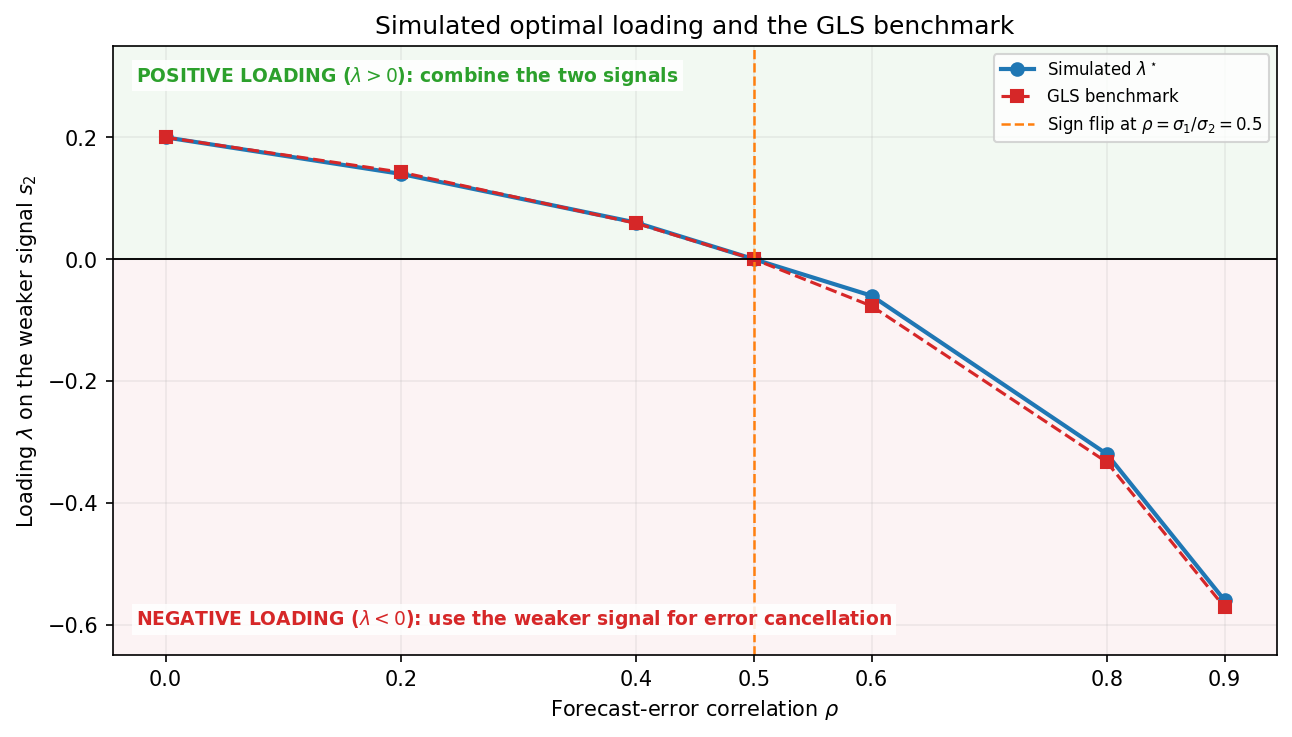

kappa_1 = 0.50, kappa_2 = 0.20; naive loading = 0.29

   rho  lambda*  GLS pred  peak dCE  naive dCE  gap (bp)
   0.0     0.20      0.20     289.0      285.2       3.8
   0.2     0.14      0.14     275.3      266.4       9.0
   0.4     0.06      0.06     266.3      251.2      15.1
   0.5     0.00      0.00     264.5      245.2      19.3
   0.6    -0.06     -0.08     265.8      239.2      26.6
   0.8    -0.32     -0.33     285.9      227.2      58.7
   0.9    -0.56     -0.57     317.8      221.2      96.6


In [9]:
# ---- Experiment 4.5 ----
sig1, sig2 = 0.05, 0.10
rho_grid  = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9]
lam_grid  = np.linspace(-0.6, 1.0, 81)     # step 0.02, fine enough not to quantise lambda*
bg_coarse = np.linspace(0.0, 120.0, 31)

def gls_lambda(rho):
    # posterior-mean loadings on (s1 - mu_bar, s2 - mu_bar), normalised to sum to one
    Cn = np.array([[sig1**2, rho*sig1*sig2], [rho*sig1*sig2, sig2**2]])
    S  = sigma_mu**2 * np.ones((2, 2)) + Cn
    lam = sigma_mu**2 * np.linalg.solve(S, np.ones(2))
    return lam[1] / lam.sum()          # loading share of the weaker signal s2

def gls_ratio(rho):
    # the same quantity in closed form: lambda* = k(k - rho)/(k^2 - 2 rho k + 1), k = sig1/sig2.
    # Two parameters, not three -- the market never enters, and the flip at k = rho is manifest.
    k = sig1 / sig2
    return k*(k - rho) / (k**2 - 2*rho*k + 1)
print("closed form vs the matrix solve: max |difference| over the rho grid = "
      f"{max(abs(gls_ratio(r) - gls_lambda(r)) for r in rho_grid):.2e}")
print(f"flip predicted at rho = sigma_1/sigma_2 = {sig1/sig2:.2f}\n")

kap1 = sigma_mu**2 / (sigma_mu**2 + sig1**2)
kap2 = sigma_mu**2 / (sigma_mu**2 + sig2**2)
lam_naive = kap2 / (kap1 + kap2)       # standalone-quality weighting, rho-blind

res42 = {}
for rho in rho_grid:
    s1 = mu + sig1 * eps0
    s2 = mu + sig2 * (rho * eps0 + np.sqrt(1 - rho**2) * e2_raw)
    curve = [best_beta((1 - lam) * s1 + lam * s2, R, grid=bg_coarse) for lam in lam_grid]
    peaks = np.array([c[0] for c in curve])
    k_opt = int(np.argmax(peaks))
    pk_naive, _ = best_beta((1 - lam_naive) * s1 + lam_naive * s2, R, grid=bg_coarse)
    res42[rho] = (lam_grid[k_opt], peaks[k_opt], pk_naive, peaks)

fig, ax = plt.subplots(figsize=(8.5, 4.8), dpi=150, constrained_layout=True)
ax.plot(rho_grid, [res42[r][0] for r in rho_grid], 'o-', lw=2, label=r'Simulated $\lambda^\star$')
ax.plot(rho_grid, [gls_lambda(r) for r in rho_grid], 's--', lw=1.5, color='tab:red',
        label='GLS benchmark')
ax.axhspan(0, 0.35, color='tab:green', alpha=0.06, zorder=0)
ax.axhspan(-0.65, 0, color='tab:red', alpha=0.05, zorder=0)
ax.axhline(0, color='black', lw=0.9)
ax.axvline(sig1 / sig2, color='tab:orange', ls='--', lw=1.2,
           label=r'Sign flip at $\rho = \sigma_1/\sigma_2 = 0.5$')
ax.set_xlabel(r'Forecast-error correlation $\rho$')
ax.set_ylabel(r'Loading $\lambda$ on the weaker signal $s_2$')
ax.set_title(r'Simulated optimal loading and the GLS benchmark')
ax.set_xticks(rho_grid)
ax.set_ylim(-0.65, 0.35)
ax.text(0.02, 0.97, r'POSITIVE LOADING ($\lambda>0$): combine the two signals',
        transform=ax.transAxes, ha='left', va='top', fontsize=9, fontweight='semibold',
        color='tab:green',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2))
ax.text(0.02, 0.04, r'NEGATIVE LOADING ($\lambda<0$): use the weaker signal for error cancellation',
        transform=ax.transAxes, ha='left', va='bottom', fontsize=9, fontweight='semibold',
        color='tab:red',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2))
ax.grid(alpha=0.2); ax.legend(fontsize=8, loc='upper right')
plt.show()

print(f"kappa_1 = {kap1:.2f}, kappa_2 = {kap2:.2f}; naive loading = {lam_naive:.2f}\n")
print(f"{'rho':>6} {'lambda*':>8} {'GLS pred':>9} {'peak dCE':>9} {'naive dCE':>10} {'gap (bp)':>9}")
for r in rho_grid:
    print(f"{r:>6} {res42[r][0]:>8.2f} {gls_lambda(r):>9.2f} {res42[r][1]:>9.1f} "
          f"{res42[r][2]:>10.1f} {res42[r][1]-res42[r][2]:>9.1f}")


## Experiment 4.6 — Recovery of classical portfolios

The final experiment asks whether the two maps can recover classical portfolio targets when their inputs are noisy. A single cross-sectional draw of $(\mu_i,\sigma_i)$ is fixed, so the target portfolios remain unchanged and all subsequent randomness comes from the observed signals.

Three targets are considered. The fully invested tangency portfolio is proportional to $\Sigma^{-1}\mu$ and may contain short positions. Its Euclidean projection onto the simplex gives the long-only target used for the softmax comparison. The GMV portfolio depends only on $\Sigma$ and is recovered through a softmax map applied to log-volatility scores. The combination map is compared with the unconstrained tangency portfolio, while the drift-only softmax map is compared with its long-only projection.

Drift noise is varied through $\sigma_\varepsilon$. Volatility is observed through the multiplicative signal

$$
\widehat\sigma_i=\sigma_i\exp\!\left(\nu\eta_i-\frac{\nu^2}{2}\right),
$$

with $\nu$ controlling log-volatility noise. For each noise setting, the code searches for the strength that minimises the expected $L_1$ distance from the relevant target. A moderate strength is expected to balance two errors: too little strength leaves the portfolio near equal weight, whereas too much strength amplifies noise in the observed inputs.

Recovery and investment performance solve different problems. The experiment therefore also compares the recovery-optimal strength with the strength that maximises M--V CE, and reports the CE cost of choosing strength only to mimic the classical target. For the combination map, comparisons use the predefined 10% normaliser rule and a common retained sample.

A final matched-information calculation makes either the drift input or the volatility input noisy while keeping the other clean. The resulting recovery distances and CE losses show which estimation error is more damaging at comparable information levels. Cross-section redraws and block checks are included to ensure that the conclusions do not depend on one fixed target or a small subset of replications.

(a) frozen cross-section: 4 of 20 drifts negative; tangency shorts 4 names (min weight -0.028)
    long-only projection of the tangency target differs from it by L1 = 0.113; GMV min weight 0.020

(b) the structural floor, decomposed
    to the long-only projection  : L1 = 0.317  <- SHAPE mismatch
    extra cost of the shorts     : L1 = +0.052  <- REACHABILITY
    to the long-short tangency   : L1 = 0.369
    common comparison sample: 26661 retained, 3339 dropped

(c) RECOVERY under noisy drift and noisy volatility: best achievable L1 distance
                                      nu=0.0                    nu=0.1                    nu=0.2
         sigma_eps    comb  sfmx LS  sfmx LO    comb  sfmx LS  sfmx LO    comb  sfmx LS  sfmx LO
               0.0   0.000    0.369    0.317   0.170    0.369    0.317   0.328    0.369    0.317
              0.05   0.515    0.628    0.567   0.534    0.628    0.567   0.579    0.628    0.567
               0.1   0.733    0.748    0.687   0.736    0.748  

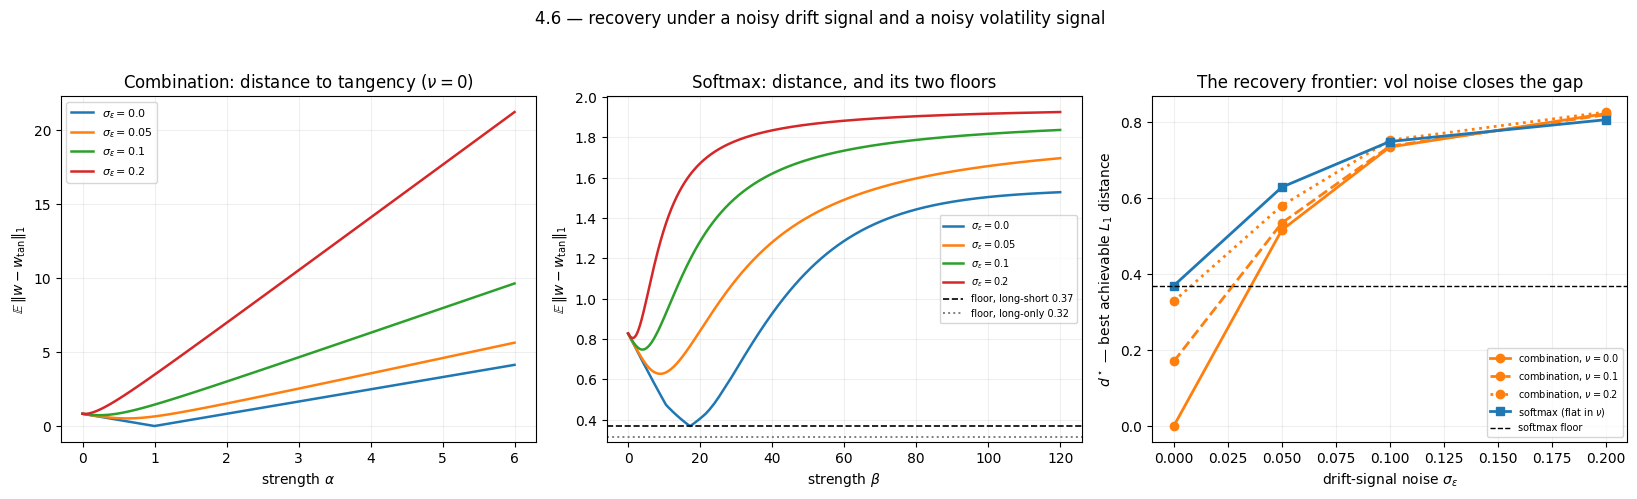

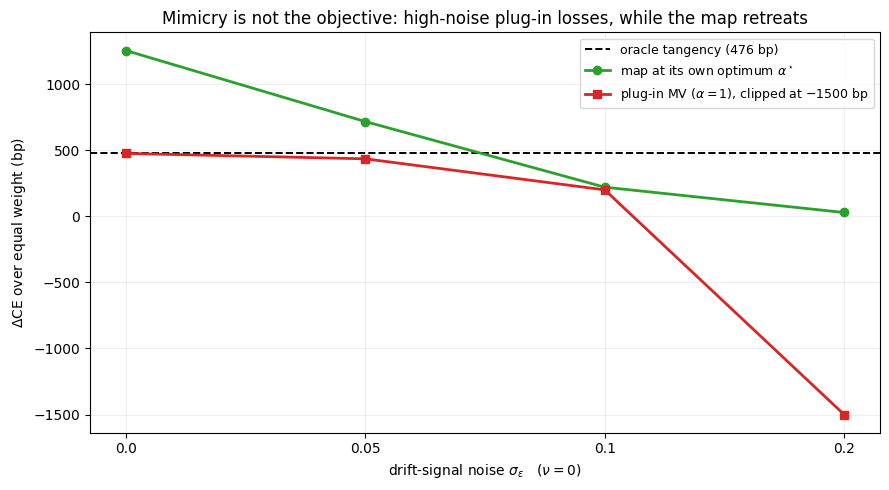

In [10]:
# ---- Experiment 4.6: recovery under noisy drift AND noisy volatility ----
# (a) one frozen cross-section and its three targets
# (b) the softmax's structural floor, decomposed into shape and shorting
# (c) recovery surfaces over the two-dimensional noise grid
# (d) the certainty-equivalent horse race
# (e) which input matters more, at matched information content
rng_fc = np.random.default_rng(4646)
mu_fc  = mu_bar + sigma_mu * rng_fc.standard_normal(N)
sig_fc = np.clip(0.20 + 0.05 * rng_fc.standard_normal(N), 0.05, None)
eta46  = rng_fc.standard_normal((n_sims, N))          # volatility-signal noise
R_fc   = np.exp((mu_fc - 0.5 * sig_fc**2) * dt + sig_fc * np.sqrt(dt) * phi) - 1.0

# --- (a) targets, all built from the TRUE parameters ---
w_tan = mu_fc / sig_fc**2; w_tan /= w_tan.sum()       # plug-in tangency: long-short
w_lo  = proj_simplex(w_tan[None, :])[0]               # the same target, projected long-only
w_gmv = 1.0 / sig_fc**2;   w_gmv /= w_gmv.sum()       # GMV: long-only already
print(f"(a) frozen cross-section: {int((mu_fc < 0).sum())} of {N} drifts negative; "
      f"tangency shorts {int((w_tan < 0).sum())} names (min weight {w_tan.min():.3f})")
print(f"    long-only projection of the tangency target differs from it by "
      f"L1 = {np.abs(w_lo - w_tan).sum():.3f}; GMV min weight {w_gmv.min():.3f}\n")

# --- (b) the floor, decomposed ---
bfine = np.arange(0.0, 400.0 + 0.25, 0.25)
fl_ls = min(np.abs(softmax_weights(mu_fc[None, :], b)[0] - w_tan).sum() for b in bfine)
fl_lo = min(np.abs(softmax_weights(mu_fc[None, :], b)[0] - w_lo ).sum() for b in bfine)
print("(b) the structural floor, decomposed")
print(f"    to the long-only projection  : L1 = {fl_lo:.3f}  <- SHAPE mismatch")
print(f"    extra cost of the shorts     : L1 = {fl_ls-fl_lo:+.3f}  <- REACHABILITY")
print(f"    to the long-short tangency   : L1 = {fl_ls:.3f}")

# --- (c)/(d) the two-dimensional noise grid ---
se_grid46 = [0.0, 0.05, 0.10, 0.20]          # drift-signal noise
nu_grid46 = [0.0, 0.10, 0.20]                # volatility-signal noise
alpha_g46 = np.linspace(0.0, 6.0, 121)       # WIDE: the CE optimum runs well past alpha = 2
beta_g46  = np.arange(0.0, 120.0 + 0.25, 0.25)
inputs46 = {}
for se in se_grid46:
    for nu in nu_grid46:
        s = mu_fc + se * eps0
        sh = sig_fc * np.exp(nu * eta46 - 0.5 * nu**2)  # mean-unbiased volatility signal
        num = s / sh**2
        inputs46[(se, nu)] = (s, num, num.sum(axis=1))
keep46 = np.logical_and.reduce([normaliser_keep(num) for _, num, _ in inputs46.values()])
R46 = R_fc[keep46]
ce0_fc = ce_of(R46.mean(axis=1))
dce_tan = 1e4 * (ce_of((w_tan * R46).sum(axis=1)) - ce0_fc)
print(f"    common comparison sample: {keep46.sum()} retained, {(~keep46).sum()} dropped\n")

def cell46(se, nu):
    s, num, ns = inputs46[(se, nu)]
    w_sig, R_m = num[keep46] / ns[keep46, None], R46
    # recovery: distance from each map to the oracle tangency target
    X, a_vec = w_sig - 1.0/N, (1.0/N) - w_tan
    D_c = np.array([np.abs(a_vec + a*X).sum(axis=1).mean() for a in alpha_g46])
    D_s_ls = np.array([np.abs(softmax_weights(s[keep46], b) - w_tan).sum(axis=1).mean() for b in beta_g46])
    D_s_lo = np.array([np.abs(softmax_weights(s[keep46], b) - w_lo ).sum(axis=1).mean() for b in beta_g46])
    # certainty equivalents
    c0 = ce_of(R_m.mean(axis=1))
    p_eq, p_sig = R_m.mean(axis=1), (w_sig * R_m).sum(axis=1)
    plug = 1e4 * (ce_of(p_sig) - c0)                           # alpha = 1: the practitioner's plug-in
    ce_a = [1e4*(ce_of((1-a)*p_eq + a*p_sig) - c0) for a in alpha_g46]
    ce_a = np.array(ce_a); kc = int(np.argmax(ce_a)); kr = int(np.argmin(D_c))
    return dict(dc=D_c[kr], a_rec=alpha_g46[kr], a_ce=alpha_g46[kc], ce_best=ce_a[kc],
                regret=ce_a[kc]-ce_a[kr] if np.isfinite(ce_a[kr]) else np.nan, plug=plug,
                ds_ls=D_s_ls.min(), b_ls=beta_g46[int(D_s_ls.argmin())],
                ds_lo=D_s_lo.min(), b_lo=beta_g46[int(D_s_lo.argmin())])

res46 = {(se, nu): cell46(se, nu) for se in se_grid46 for nu in nu_grid46}

print("(c) RECOVERY under noisy drift and noisy volatility: best achievable L1 distance")
print(f"{'':>18}" + "".join(f"{f'nu={nu}':>26}" for nu in nu_grid46))
print(f"{'sigma_eps':>18}" + "".join(f"{'comb':>8}{'sfmx LS':>9}{'sfmx LO':>9}" for _ in nu_grid46))
for se in se_grid46:
    row = "".join(f"{res46[(se,nu)]['dc']:>8.3f}{res46[(se,nu)]['ds_ls']:>9.3f}"
                  f"{res46[(se,nu)]['ds_lo']:>9.3f}" for nu in nu_grid46)
    print(f"{se:>18}" + row)
print("    recovery-optimal strengths (combination alpha by nu; softmax beta to long-only target)")
for se in se_grid46:
    avec = ', '.join(f"{res46[(se,nu)]['a_rec']:.2f}" for nu in nu_grid46)
    print(f"      sigma_eps={se:.2f}: alpha_rec = [{avec}]; beta_rec = {res46[(se,0.0)]['b_lo']:.2f}")
print()

print("(d) THE CERTAINTY-EQUIVALENT HORSE RACE, bp over equal weight")
print(f"    oracle tangency (true mu, true sigma), held as a portfolio: {dce_tan:.1f} bp")
print(f"{'sigma_eps':>10}{'nu':>6} | {'plug-in MV':>12}{'map @ CE opt':>14}{'alpha*':>8}"
      f"{'alpha_rec':>11}{'regret bp':>11}")
for se in se_grid46:
    for nu in nu_grid46:
        r = res46[(se, nu)]
        print(f"{se:>10}{nu:>6} | {r['plug']:>12.1f}{r['ce_best']:>14.1f}{r['a_ce']:>8.2f}"
              f"{r['a_rec']:>11.2f}{r['regret']:>11.1f}")
print("    'plug-in MV' is alpha = 1 with the noisy inputs -- what a practitioner actually holds.")

# --- the closed-form check: in L2 the combination objective is an exact quadratic in alpha ---
def a_rec_closed(se, nu):
    _, num, ns = inputs46[(se, nu)]
    X = num[keep46] / ns[keep46, None] - 1.0/N
    a_vec = (1.0/N) - w_tan
    return -(a_vec * X.mean(axis=0)).sum() / (X**2).sum(axis=1).mean()

print(f"\n    closed-form check on the recovering strength (L2 minimiser vs the L1 grid minimiser):")
print(f"{'sigma_eps':>10}{'nu':>6}{'a_rec (L1)':>12}{'closed form':>13}")
for se in se_grid46:
    for nu in nu_grid46:
        print(f"{se:>10}{nu:>6}{res46[(se,nu)]['a_rec']:>12.2f}{a_rec_closed(se,nu):>13.2f}")

# ---------------- (e) which input matters more, at matched information content ----------------
d_lv = np.log(sig_fc).std()
print(f"\n(e) WHICH INPUT MATTERS MORE, AT MATCHED INFORMATION CONTENT")
print(f"    log-volatility dispersion of the frozen cross-section: d = {d_lv:.4f}")
print(rule)
print(rule)

def one_channel(kap):
    """Degrade one channel to retain fraction kap of its information, holding the other clean."""
    f  = 0.0 if kap >= 1.0 else np.sqrt((1.0-kap)/kap)
    se, nu = sigma_mu*f, d_lv*f
    pairs = []
    for s_e, n_u in [(se, 0.0), (0.0, nu)]:
        s = mu_fc + s_e*eps0
        sh = sig_fc*np.exp(n_u*eta46 - 0.5*n_u**2)
        num = s/sh**2
        pairs.append((s_e, n_u, num, num.sum(axis=1)))
    keep = np.logical_and.reduce([normaliser_keep(num) for _, _, num, _ in pairs])
    out = []
    for s_e, n_u, num, ns in pairs:
        w_sig, R_m = num[keep]/ns[keep, None], R_fc[keep]
        X, a_vec = w_sig - 1.0/N, (1.0/N) - w_tan
        dstar = min(np.abs(a_vec + a*X).sum(axis=1).mean() for a in alpha_g46)
        c0 = ce_of(R_m.mean(axis=1))
        p_eq, p_sig = R_m.mean(axis=1), (w_sig*R_m).sum(axis=1)
        best = max(1e4*(ce_of((1-a)*p_eq + a*p_sig) - c0) for a in alpha_g46)
        out += [se if n_u == 0 else nu, dstar, best]
    return out

print(f"{'information kept':>17} | {'sigma_eps':>10}{'distance':>10}{'dCE':>9} | "
      f"{'nu':>7}{'distance':>10}{'dCE':>9} | {'drift/vol: dist':>16}{'dCE':>8}")
print(rule)
for kap in [0.75, 0.50, 0.25]:
    se, dd, cd, nu, dv, cv = one_channel(kap)
    print(f"{kap:>16.0%} | {se:>10.3f}{dd:>10.3f}{cd:>9.0f} | {nu:>7.3f}{dv:>10.3f}{cv:>9.0f} | "
          f"{dd/dv:>15.2f}x{(res46[(0.0,0.0)]['ce_best']-cd)/(res46[(0.0,0.0)]['ce_best']-cv):>7.2f}x")
print(rule)
print()

# ---------------- figures ----------------
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
ax = axes[0]
for se in se_grid46:
    s = mu_fc + se*eps0; num = s/sig_fc**2; ns = num.sum(axis=1)
    X = num[keep46]/ns[keep46, None] - 1.0/N; a_vec = (1.0/N) - w_tan
    ax.plot(alpha_g46, [np.abs(a_vec + a*X).sum(axis=1).mean() for a in alpha_g46],
            lw=1.8, label=fr'$\sigma_\varepsilon={se}$')
ax.set_xlabel(r'strength $\alpha$'); ax.set_ylabel(r'$\mathbb{E}\,\|w-w_{\mathrm{tan}}\|_1$')
ax.set_title(r'Combination: distance to tangency ($\nu=0$)')
ax.grid(alpha=0.2); ax.legend(fontsize=8)

ax = axes[1]
for se in se_grid46:
    s = mu_fc + se*eps0
    ax.plot(beta_g46, [np.abs(softmax_weights(s[keep46], b) - w_tan).sum(axis=1).mean() for b in beta_g46],
            lw=1.8, label=fr'$\sigma_\varepsilon={se}$')
ax.axhline(fl_ls, color='black', ls='--', lw=1.2, label=f'floor, long-short {fl_ls:.2f}')
ax.axhline(fl_lo, color='tab:grey', ls=':', lw=1.4, label=f'floor, long-only {fl_lo:.2f}')
ax.set_xlabel(r'strength $\beta$'); ax.set_ylabel(r'$\mathbb{E}\,\|w-w_{\mathrm{tan}}\|_1$')
ax.set_title('Softmax: distance, and its two floors')
ax.grid(alpha=0.2); ax.legend(fontsize=7)

ax = axes[2]
for nu, ls in zip(nu_grid46, ['-', '--', ':']):
    ax.plot(se_grid46, [res46[(se, nu)]['dc'] for se in se_grid46], 'o'+ls, lw=2,
            color='tab:orange', label=fr'combination, $\nu={nu}$')
ax.plot(se_grid46, [res46[(se, 0.0)]['ds_ls'] for se in se_grid46], 's-', lw=2, color='tab:blue',
        label=r'softmax (flat in $\nu$)')
ax.axhline(fl_ls, color='black', ls='--', lw=1, label='softmax floor')
ax.set_xlabel(r'drift-signal noise $\sigma_\varepsilon$')
ax.set_ylabel(r'$d^\star$ — best achievable $L_1$ distance')
ax.set_title(r'The recovery frontier: vol noise closes the gap')
ax.grid(alpha=0.2); ax.legend(fontsize=7)
plt.suptitle('4.6 — recovery under a noisy drift signal and a noisy volatility signal', y=1.03)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(se_grid46))
ax.axhline(dce_tan, color='black', ls='--', lw=1.4, label=f'oracle tangency ({dce_tan:.0f} bp)')
ax.plot(x, [res46[(se, 0.0)]['ce_best'] for se in se_grid46], 'o-', lw=2, color='tab:green',
        label=r'map at its own optimum $\alpha^\star$')
ax.plot(x, [max(res46[(se, 0.0)]['plug'], -1500) for se in se_grid46], 's-', lw=2, color='tab:red',
        label=r'plug-in MV ($\alpha=1$), clipped at $-1500$ bp')
ax.set_xticks(x); ax.set_xticklabels([str(s) for s in se_grid46])
ax.set_xlabel(r'drift-signal noise $\sigma_\varepsilon$   ($\nu = 0$)')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title('Mimicry is not the objective: high-noise plug-in losses, while the map retreats')
ax.grid(alpha=0.2); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


In [11]:
# ---- GMV via the log-vol signal; block-split and cross-section robustness ----
# (a) GMV is ON the softmax family: softmax(beta * (-2 ln sighat)) = GMV exactly at beta=1, nu=0.
print("(a) GMV recovery through the softmax log-vol signal")
beta_gmv = np.linspace(0.0, 2.0, 81)
for nu in [0.0, 0.05, 0.10, 0.20]:
    sighat = sig_fc * np.exp(nu * eta46 - 0.5 * nu**2)
    s_lv = -2.0 * np.log(sighat)
    D = [np.abs(softmax_weights(s_lv, b) - w_gmv).sum(axis=1).mean() for b in beta_gmv]
    k = int(np.argmin(D))
    print(f"  nu={nu}: min distance {D[k]:.4f} at beta_rec = {beta_gmv[k]:.2f}")

# (b) one seed vs many: split the 30k replications into 6 blocks (equivalent to 6 seeds)
print("\n(b) block-split stability of the baseline recovery numbers (sigma_eps = 0.05)")
se_b = 0.05
s_b = mu_fc + se_b * eps0
blocks = np.array_split(np.arange(n_sims), 6)
stats = []
for blk in blocks:
    D1 = [np.abs(softmax_weights(s_b[blk], b) - w_tan).sum(axis=1).mean() for b in beta_g46]
    k = int(np.argmin(D1)); stats.append((D1[k], beta_g46[k]))
d_blk = np.array([x[0] for x in stats]); b_blk = np.array([x[1] for x in stats])
print(f"  softmax d* across 6 blocks: mean {d_blk.mean():.3f}, sd {d_blk.std(ddof=1):.4f} "
      f"| beta_rec: mean {b_blk.mean():.0f}, sd {b_blk.std(ddof=1):.1f}")

# (c) the frozen cross-section is a conditioning choice: three alternative draws
print("\n(c) three alternative cross-sections (headline numbers at sigma_eps = 0.05)")
for seed in [4646, 4647, 4648]:
    r2 = np.random.default_rng(seed)
    m2 = mu_bar + sigma_mu * r2.standard_normal(N)
    s2 = np.clip(0.20 + 0.05 * r2.standard_normal(N), 0.05, None)
    wt = m2 / s2**2; wt /= wt.sum()
    fl = min(np.abs(softmax_weights(m2[None, :], b)[0] - wt).sum() for b in np.linspace(0, 400, 801))
    sg = m2 + se_b * eps0
    num = sg / s2**2; ns = num.sum(axis=1)
    mm = np.abs(ns) > 0.10 * np.median(np.abs(ns))
    Ds = min(np.abs(softmax_weights(sg[mm], b) - wt).sum(axis=1).mean() for b in beta_g46)
    ws = num[mm] / ns[mm, None]
    Dc = min(np.abs((1/N - wt) + a * (ws - 1/N)).sum(axis=1).mean() for a in alpha_g46)
    print(f"  seed {seed}: shorts in tangency {int((wt<0).sum()):>2} | "
          f"softmax floor (long-short) {fl:.3f}, d* {Ds:.3f} | combination d* {Dc:.3f}")

# (d) paired Monte Carlo uncertainty for the main CE comparison. The strength is fixed at the
print("\n(d) paired block uncertainty for the CE horse race (sigma_eps=0.05, nu=0)")
a_full = res46[(0.05, 0.0)]['a_ce']
_, num_b, ns_b = inputs46[(0.05, 0.0)]
ce_blocks = []
for blk in np.array_split(np.flatnonzero(keep46), 6):
    p0 = R_fc[blk].mean(axis=1)
    ps = ((num_b[blk] / ns_b[blk, None]) * R_fc[blk]).sum(axis=1)
    c0 = ce_of(p0)
    ce_blocks.append((1e4*(ce_of(ps)-c0), 1e4*(ce_of((1-a_full)*p0+a_full*ps)-c0)))
ce_blocks = np.asarray(ce_blocks)
for j, lab in enumerate(['plug-in (alpha=1)', f'map (alpha={a_full:.2f})']):
    print(f"  {lab:>20}: mean {ce_blocks[:,j].mean():8.1f} bp, "
          f"MC SE {ce_blocks[:,j].std(ddof=1)/np.sqrt(len(ce_blocks)):5.1f} bp")

# (e) the combination map is singular at a zero normaliser, so its reported estimand is
print("\n(e) normaliser-threshold sensitivity (nu=0; setting-specific retained samples)")
print(f"{'threshold':>10}{'sigma_eps':>12}{'dropped':>10}{'plug-in':>12}{'map best':>12}{'alpha*':>9}")
for thr in [0.05, 0.10, 0.20]:
    for se in [0.05, 0.10, 0.20]:
        _, num_t, ns_t = inputs46[(se, 0.0)]
        kt = normaliser_keep(num_t, threshold=thr)
        p0 = R_fc[kt].mean(axis=1)
        ps = ((num_t[kt]/ns_t[kt, None])*R_fc[kt]).sum(axis=1)
        c0 = ce_of(p0); curve = np.array([1e4*(ce_of((1-a)*p0+a*ps)-c0) for a in alpha_g46])
        k = int(curve.argmax())
        print(f"{thr:>10.0%}{se:>12.2f}{(~kt).sum():>10}{1e4*(ce_of(ps)-c0):>12.1f}"
              f"{curve[k]:>12.1f}{alpha_g46[k]:>9.2f}")


(a) GMV recovery through the softmax log-vol signal
  nu=0.0: min distance 0.0000 at beta_rec = 1.00
  nu=0.05: min distance 0.0741 at beta_rec = 0.93
  nu=0.1: min distance 0.1323 at beta_rec = 0.73
  nu=0.2: min distance 0.1990 at beta_rec = 0.43

(b) block-split stability of the baseline recovery numbers (sigma_eps = 0.05)
  softmax d* across 6 blocks: mean 0.631, sd 0.0006 | beta_rec: mean 9, sd 0.1

(c) three alternative cross-sections (headline numbers at sigma_eps = 0.05)
  seed 4646: shorts in tangency  4 | softmax floor (long-short) 0.371, d* 0.631 | combination d* 0.523
  seed 4647: shorts in tangency  2 | softmax floor (long-short) 0.473, d* 0.652 | combination d* 0.454
  seed 4648: shorts in tangency  3 | softmax floor (long-short) 0.347, d* 0.658 | combination d* 0.617

(d) paired block uncertainty for the CE horse race (sigma_eps=0.05, nu=0)
     plug-in (alpha=1): mean    435.4 bp, MC SE   3.8 bp
      map (alpha=2.70): mean    717.4 bp, MC SE  12.1 bp

(e) normaliser-th

## Methodological notes

- **Common random numbers.** Within each comparison, the same market and signal-error draws are reused across strength values and competing portfolios. This makes differences paired and reduces Monte-Carlo noise. New random objects use separate seeded streams so earlier experiments are unchanged.
- **Grid searches.** Strength grids are widened where a preliminary optimum reaches an endpoint. Top-$k$ signals are an exception: their CE is monotone in strength and the limiting equal-weight top-$k$ portfolio is a structural boundary rather than a missed interior optimum.
- **Numerical solvers.** The entropy-regularised fixed point is checked for convergence. Sparse M--V solutions use water-filling where available and projected gradient with a valid Lipschitz constant under the factor model.
- **Combination-map domain.** When the normaliser approaches zero, the ratio map is ill-conditioned. Comparisons therefore use the stated threshold and the intersection of setting-specific masks. The resulting values are conditional on this domain rule, whose sensitivity is reported where relevant.
- **Outcome-informed benchmarks.** The diffusion-information dial and top-$k$ signals intentionally contain information about realised outcomes. They measure informational value under the model and are not proposed as implementable strategies.
- **Robustness.** Depending on the experiment, checks include alternative market regimes, factor-loading redraws, cross-section redraws, and replication blocks. These address parameter dependence separately from ordinary Monte-Carlo variation.

The notebook retains the numerical tables, figures, convergence diagnostics, and validation checks needed to reproduce the chapter. Longer interpretation and practitioner implications are kept in the dissertation to avoid duplicating the report inside the code submission.